In [3]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
from pathlib import Path

notebook_name = "lidar_years_data_understanding"

# Save figures beside this notebook, even if Jupyter starts at the project root.
starting_directory = Path.cwd().resolve()
repository_root = next(
    folder for folder in [starting_directory, *starting_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
notebook_directory = repository_root / "data_exploration_gpkg" / "notebooks"
output_directory = notebook_directory / "figures" / notebook_name
output_directory.mkdir(parents=True, exist_ok=True)


# LiDAR Years: data understanding

Exploration of the corrected `LiDAR_Years.gpkg` attribute export. Results in this notebook must be calculated from the new data and should not be copied from the archived 29 June notebook.

In [5]:
# Find the repository root whether Jupyter starts there or in notebooks/.
current_directory = Path.cwd().resolve()
project_root = next(
    folder
    for folder in [current_directory, *current_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

data_path = project_root / "data" / "interim" / "LiDAR_Years_attributes.csv"

if not data_path.exists():
    raise FileNotFoundError(
        "Attribute CSV not found. Run: "
        ".venv/bin/python data_preprocessing/open_gpkg_file.py"
    )

data_path

PosixPath('/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/data/interim/LiDAR_Years_attributes.csv')

In [6]:
attribute_table = pd.read_csv(data_path, low_memory=False)

In [7]:
attribute_table.shape

(550948, 23)

In [8]:
pd.set_option("display.max_columns", None)
display(attribute_table.head())

,CanopyCover,GapFraction,LAI,elev_percentile_95th,AOI,LiDAR_year,block,identification,SPIS_RF,code,blk,cpmt,scpt,display_id,spis,plyr,yldc,next_thin_,last_thinn,area,Age,Top_Height,Vol
0,0.046377,0.953623,0.022686,7.902629,Aberfoyle,2002,30,164,NaN,NaN,30,2180,C,701 30 2180 C,NaN,0,0,0,0,400.000000,2002,8.692892,0.212173
1,0.525164,0.474836,0.355802,9.895923,Aberfoyle,2002,30,216,NaN,NaN,30,2180,C,701 30 2180 C,NaN,0,0,0,0,421.738550,2002,10.885515,3.913231
2,0.089524,0.910476,0.044805,8.871577,Aberfoyle,2002,30,217,NaN,NaN,30,2180,C,701 30 2180 C,NaN,0,0,0,0,317.766205,2002,9.758735,0.408839
3,0.133238,0.866762,0.068310,6.332562,Aberfoyle,2002,30,219,NaN,NaN,30,2180,C,701 30 2180 C,NaN,0,0,0,0,685.007732,2002,6.965818,0.647048
4,0.270769,0.729231,0.150849,10.394059,Aberfoyle,2002,30,220,NaN,NaN,30,2180,C,701 30 2180 C,NaN,0,0,0,0,557.386262,2002,11.433465,2.919010


## Data exploration plan

### 1. Basic data checks

- [ ] Check the number of rows and columns
- [ ] Check the data type of each column
- [ ] Count missing values and calculate the percentage missing
- [ ] Check whether missing values follow a pattern
- [ ] Check for fully duplicated rows
- [ ] Check for duplicated IDs or repeated observations

### 2. Understand the data

- [ ] Find out what each column means and what its units are
- [ ] Group columns by type, such as LiDAR, forest, location, and ID columns
- [ ] Calculate summary statistics for numerical columns
- [ ] Count the unique values in category columns
- [ ] Check which years and forest areas are included
- [ ] Work out what one row represents

### 3. Explore values and distributions

- [ ] Plot histograms for the main numerical variables
- [ ] Plot bar charts for important categories
- [ ] Use box plots to find possible outliers
- [ ] Look more closely at unusual or impossible values

### 4. Compare variables

- [ ] Check correlations between numerical variables
- [ ] Create scatter plots for important relationships
- [ ] Compare results between years, areas, and forest groups
- [ ] Look for changes over time where the same places were measured again

### 5. Explore the spatial data

- [ ] Check the coordinate system and geometry type
- [ ] Check for missing, empty, or invalid geometries
- [ ] Map the overall study area and data coverage
- [ ] Map coverage for each LiDAR year
- [ ] Map important variables such as canopy cover, LAI, height, and volume
- [ ] Map missing values and unusual values to see whether they form spatial patterns

### 6. Record what we learn

- [ ] Write down the main findings after each section
- [ ] Record any data problems and questions
- [ ] Decide which questions need their own analysis notebook

# 1. Basic data checks

The aim of these checks is to find simple problems before we analyse the data. We will check the table size, column types, missing values, and duplicates. These checks do not change the data.

## 1.1 Dataset size and structure

First, we check how large the table is and what kind of values each column stores.

In [9]:
# Aim: check the table size, column types, and survey years.
print(f"Rows: {attribute_table.shape[0]:,}")
print(f"Columns: {attribute_table.shape[1]}")
print(f"LiDAR years: {sorted(attribute_table['LiDAR_year'].unique())}")

attribute_table.dtypes.to_frame(name="data_type")

Rows: 550,948
Columns: 23
LiDAR years: [np.int64(2002), np.int64(2006), np.int64(2008), np.int64(2012), np.int64(2021), np.int64(2023)]


,data_type
CanopyCover,float64
GapFraction,float64
LAI,float64
elev_percentile_95th,float64
AOI,str
LiDAR_year,int64
block,int64
identification,int64
SPIS_RF,float64
code,str


**Findings 1.1 – Dataset size and structure**

The dataset contains **550,948 rows and 23 columns**. Each row is one LiDAR measurement record for one 20 m × 20 m plot polygon in one survey year.

Six surveys span 21 years: **2002, 2006, 2008, 2012, 2021, and 2023**. Survey sizes are very unequal — 2002 and 2006 together account for only ~16% of all rows, while 2021 and 2023 each contribute ~22%. There is jump in coverage from 2006 to 2008 (32,745 → 103,412 rows).

All numeric columns loaded with expected types. No column was silently misread as a string.

## 1.2 Missing values (NaN)

The aim is to find which columns have gaps. Missing values are not removed at this stage.

In [10]:
# 1. Show every column containing NaN values
missing = attribute_table.isna().sum()
display(missing[missing > 0].to_frame("missing_rows"))

# 2. Check whether spid_rf and code are missing together
spid_missing = attribute_table["SPIS_RF"].isna()
code_missing = attribute_table["code"].isna()

display(pd.Series({
    "both missing": (spid_missing & code_missing).sum(),
    "SPIS_RF only missing": (spid_missing & ~code_missing).sum(),
    "code only missing": (~spid_missing & code_missing).sum(),
    "neither missing": (~spid_missing & ~code_missing).sum(),
}).to_frame("rows"))

,missing_rows
SPIS_RF,115542
code,115542
spis,118182


,rows
both missing,115542
SPIS_RF only missing,0
code only missing,0
neither missing,435406


**Findings 1.2 – Missing values**

Only three columns contain `NaN`, and they all describe species or species-model output:
- `SPIS_RF` and `code`: **115,542 missing rows (20.97%)** — the random-forest-predicted species and its class code.
- `spis`: **118,182 missing rows (21.45%)** — the manually recorded species label from the sub-compartment database.

Notably, `spis` has **2,640 more missing entries** than `SPIS_RF`, meaning that a small set of plots has a model prediction but no manual species label. All three columns are missing for the same core set of ~115,542 plots.

All other columns — including geometry, LiDAR measurements, and derived forestry variables — are fully populated with no `NaN`s. However, "no NaN" does not mean "no missing data": Section 1.5 shows that zeros in `plyr`, `yldc`, and `next_thin_` are used as a missing-data sentinel for ~21% of plots.

**Questions for domain experts:**
- For the ~118,182 rows with no `spis`, is assuming **Sitka spruce** (`SS`) a reasonable default for Aberfoyle? `SS` is the dominant species (256,655 records, 46.6% of all labelled records).
- Why do 2,640 plots have a model-predicted species (`SPIS_RF`) but no manual `spis` label? Are these recently established stands, clearfelled ground, or data entry gaps in the SCDB?

## 1.3 Exact duplicate rows

This check looks for rows where every value is exactly the same.

In [11]:
# Aim: find rows that are exactly the same in every column.
# Exact copies may be accidental, so we count them before doing any analysis.
number_of_full_duplicates = attribute_table.duplicated().sum()

print(f"Fully duplicated rows: {number_of_full_duplicates:,}")

Fully duplicated rows: 0


**Findings 1.3 – Exact duplicate rows**

There are **0 fully duplicated rows**. No two rows are identical across all 23 columns, so the dataset contains no accidental exact copies. This is reassuring but does not rule out repeated plot/year measurements where the two records have small differences — those are found in Section 1.4.

## 1.4 Plot IDs through time

Each `identification` value represents a 20 m × 20 m plot. An ID appearing in different years is expected because the same plot can be measured again.

In [12]:
# Aim: check whether the same ID appears more than once.
# A repeated ID is not always a mistake. It may mean that the same place
# was measured in more than one year, so we also check ID and year together.
id_column = "identification"
id_counts = attribute_table[id_column].value_counts(dropna=False)

number_of_unique_ids = attribute_table[id_column].nunique(dropna=True)
number_of_repeated_ids = (id_counts > 1).sum()
# Count extra rows where the same plot ID and LiDAR year have already appeared.
repeated_id_and_year_rows = attribute_table.duplicated(
    subset=[id_column, "LiDAR_year"]).sum() # The first row in each plot/year group is not counted as a duplicate.

print(f"Unique IDs: {number_of_unique_ids:,}")
print(f"IDs that appear more than once: {number_of_repeated_ids:,}")
print(f"Repeated ID and year combinations: {repeated_id_and_year_rows:,}")

Unique IDs: 129,956
IDs that appear more than once: 128,445
Repeated ID and year combinations: 1,837


In [13]:
# Aim: count plots and repeated ID/year pairs in each year.
id_year_counts = (
    attribute_table
    .groupby(["LiDAR_year", "identification"])
    .size()
)

year_summary = (
    attribute_table
    .groupby("LiDAR_year")
    .agg(
        number_of_rows=("identification", "size"),
        number_of_unique_ids=("identification", "nunique"),
    )
)

year_summary["repeated_id_year_pairs"] = (
    id_year_counts.gt(1)
    .groupby(level="LiDAR_year")
    .sum()
)

# Every repeated ID/year group contains two rows.
year_summary["rows_in_repeated_pairs"] = (
    year_summary["repeated_id_year_pairs"] * 2
)

year_summary["percentage_of_rows_in_pairs"] = (
    year_summary["rows_in_repeated_pairs"]
    .div(year_summary["number_of_rows"])
    .mul(100)
    .round(2)
)

year_summary

,number_of_rows,number_of_unique_ids,repeated_id_year_pairs,rows_in_repeated_pairs,percentage_of_rows_in_pairs
LiDAR_year,,,,,
2002,54857,54692,165,330,0.60
2006,32745,32663,82,164,0.50
2008,103412,103058,354,708,0.68
2012,110425,110053,372,744,0.67
2021,124695,124261,434,868,0.70
2023,124814,124384,430,860,0.69


In [14]:
# Aim: compare each survey year with the survey before it.
#
# Retained = present in both years.
# Added = absent from the previous year but present in the current year.
# Dropped = present in the previous year but absent from the current year.

years = sorted(attribute_table["LiDAR_year"].unique())

ids_by_year = {
    year: set(
        attribute_table.loc[
            attribute_table["LiDAR_year"] == year,
            "identification",]) for year in years}

year_changes = []

for previous_year, current_year in zip(years[:-1], years[1:]):# E.g. 2002 with 2006, then 2006 with 2008.
    previous_ids = ids_by_year[previous_year]
    current_ids = ids_by_year[current_year]

    retained_ids = previous_ids & current_ids
    added_ids = current_ids - previous_ids
    dropped_ids = previous_ids - current_ids

    year_changes.append({
        "previous_year": previous_year,
        "current_year": current_year,
        "retained_ids": len(retained_ids),
        "added_ids": len(added_ids),
        "dropped_ids": len(dropped_ids),
        "retained_percentage": round(
            len(retained_ids) / len(previous_ids) * 100, 2
        ),
    })

year_changes = pd.DataFrame(year_changes)
year_changes

,previous_year,current_year,retained_ids,added_ids,dropped_ids,retained_percentage
0,2002,2006,28723,3940,25969,52.52
1,2006,2008,31575,71483,1088,96.67
2,2008,2012,98903,11150,4155,95.97
3,2012,2021,106276,17985,3777,96.57
4,2021,2023,121924,2460,2337,98.12


In [47]:
id_years = (
    attribute_table.groupby("identification")["LiDAR_year"]
    .agg(set))

X = id_years.apply({2002, 2006, 2008, 2012, 2021, 2023}.issubset).sum()
Y = id_years.apply({2008, 2012, 2021, 2023}.issubset).sum()

print("X:", X)
print("Y:", Y)

X: 26387
Y: 93505


In [48]:
previous_survey = {
    2006: 2002,
    2008: 2006,
    2012: 2008,
    2021: 2012,
    2023: 2021,
}

expected_previous_year = (
    plot_changes["LiDAR_year"].map(previous_survey)
)

non_consecutive = (
    plot_changes["previous_year"] != expected_previous_year
)

print(
    "Non-consecutive comparisons:",
    non_consecutive.sum()
)

print(
    "Plots involved:",
    plot_changes.loc[
        non_consecutive,
        "identification"
    ].nunique()
)

non_consecutive_summary = (
    plot_changes.loc[non_consecutive]
    .groupby(["previous_year", "LiDAR_year"])
    .size()
    .reset_index(name="comparisons")
)

display(non_consecutive_summary)

Non-consecutive comparisons: 31754
Plots involved: 31115


,previous_year,LiDAR_year,comparisons
0,2002.0,2008,22333
1,2002.0,2012,1231
2,2002.0,2021,2313
3,2002.0,2023,52
4,2006.0,2012,388
5,2006.0,2021,650
6,2006.0,2023,16
7,2008.0,2021,3260
8,2008.0,2023,644
9,2012.0,2023,867


**Findings 1.4 – Plot IDs through time**

Unique plot counts per year:

| Year | Rows | Unique plot IDs | Extra rows (dup ID/year) |
|------|------|-----------------|--------------------------|
| 2002 | 54,857 | 54,692 | 165 |
| 2006 | 32,745 | 32,663 | 82 |
| 2008 | 103,412 | 103,058 | 354 |
| 2012 | 110,425 | 110,053 | 372 |
| 2021 | 124,695 | 124,261 | 434 |
| 2023 | 124,814 | 124,384 | 430 |

Two things stand out:

1. **The 2006 → 2008 expansion**: 71,483 new plot IDs were added — the total more than tripled in two years. The opposite happened between 2002 and 2006: coverage *contracted* by ~22,000 plots. These are not gradual changes and suggest a fundamental change in survey design or spatial extent, not just forest change.

2. **Repeated ID/year pairs**: Every year contains a small number of plot IDs that appear twice with different attribute values (165–434 extra rows per year, 1,837 total). These are not exact duplicates and remain unresolved — they may indicate overlapping LiDAR tiles or a GIS merge artefact.

**Plot continuity across surveys:**
- **26,387 plots** appear in all six survey years — these form the best temporal sequence for modelling (2002–2023, 28.83% of all plot–year records).
- **93,505 plots** appear in all four surveys from 2008 onwards — a larger set suitable for a 2008–2023 spatial analysis (81.00% of those records).

Non-consecutive comparisons (e.g. a plot ID present in 2002 and 2012 but absent in between) - what happened (how many of these exist) (31754 plots)

**Questions for domain experts:**
- Was the survey boundary extended in 2008? Does the areal coverage map explain the jump from 32,663 to 103,058 plots? -- ANS = NO, this is all that is available
- Why did the 2006 survey cover fewer plots than 2002? Was a different flight path or sensor used? -- ANS = different flight coverage
- Are plot IDs (`identification`) guaranteed to represent the same polygon boundary across all surveys, or were sub-compartment boundaries redrawn? -- ANS = they reflect the same boundaries, (need to check/prove myself)

In [ ]:
# Aim: show how many columns differ for every repeated plot and year.
repeated_id_years = (
    id_year_counts[id_year_counts > 1]
    .rename("rows_for_id_and_year")
    .reset_index()
)

repeated_rows = attribute_table.merge(
    repeated_id_years,
    on=["LiDAR_year", "identification"],
    how="inner",
)

key_columns = ["LiDAR_year", "identification"]
columns_to_compare = [
    column
    for column in attribute_table.columns
    if column not in key_columns
]

# True means that a column has different values across the two rows.
differences_by_plot = (
    repeated_rows
    .groupby(key_columns)[columns_to_compare]
    .nunique(dropna=False)
    .gt(1)
)

repeated_plot_summary = (
    differences_by_plot
    .sum(axis=1)
    .rename("number_of_columns_that_differ")
    .reset_index()
)

repeated_plot_summary["columns_that_differ"] = (
    differences_by_plot
    .apply(
        lambda row: ", ".join(row.index[row].tolist()),
        axis=1,
    )
    .values
)

# Show the first ten repeated plots.
display(repeated_plot_summary.head(10))

# Show how common each number of differences is.
display(
    repeated_plot_summary["number_of_columns_that_differ"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_columns_that_differ")
    .reset_index(name="number_of_repeated_plot_years")
)

## 1.5 Values recorded as zero

Some forestry columns contain many zeros. The aim is to check whether zero is a real value or a way of recording missing information.

In [ ]:
# Aim: count meaningful zero values without treating them as ordinary missing data.

zero_columns = ["plyr", "yldc", "next_thin_", "last_thinn"]
zero_flags = attribute_table[zero_columns].eq(0)

zero_summary = pd.DataFrame({
    "zero_rows": zero_flags.sum(),
    "zero_percentage": zero_flags.mean().mul(100).round(2),
})

print(f"Rows with at least one of these zeros (from [plyr, yldc, next_thin_, last_thinn]): {zero_flags.any(axis=1).sum():,}")
print(f"Percentage with at least one zero: {zero_flags.any(axis=1).mean() * 100:.2f}%")
display(zero_summary)

# Check the numerical columns that were not included above.
measurement_columns = [
    "CanopyCover", "GapFraction", "LAI",
    "elev_percentile_95th", "Top_Height", "Vol",]
measurement_zero_check = pd.DataFrame({
    "minimum_value": attribute_table[measurement_columns].min(),
    "exact_zero_rows": attribute_table[measurement_columns].eq(0).sum(),})

# A zero identifier would be invalid, so check for it separately.
identifier_columns = ["identification", "block", "blk", "cpmt"]
identifier_zero_check = pd.DataFrame({
    "minimum_value": attribute_table[identifier_columns].min(),
    "zero_rows": attribute_table[identifier_columns].eq(0).sum(),
})

# Text and classification columns use missing-value checks, not zero checks.
category_columns = [
    "AOI", "display_id", "scpt", "spis",
    "code", "SPIS_RF",
]
category_missing_check = (
    attribute_table[category_columns].isna().sum().to_frame("missing_rows")
)

# Check area, survey year, and calculated age using suitable rules.
other_column_checks = pd.Series({
    "area at or below zero": attribute_table["area"].le(0).sum(),
    "LiDAR year at or below zero": attribute_table["LiDAR_year"].le(0).sum(),
    "negative Age": attribute_table["Age"].lt(0).sum(),
    "Age over 200": attribute_table["Age"].gt(200).sum(),
    "Age formula disagreements": (
        attribute_table["Age"]
        != attribute_table["LiDAR_year"] - attribute_table["plyr"]
    ).sum(),
}, name="rows")

print("LiDAR measurement checks")
display(measurement_zero_check)
print("Identifier checks")
display(identifier_zero_check)
print("Text and classification missing-value checks")
display(category_missing_check)
print("Area, survey year, and age checks")
other_column_checks.to_frame()

In [ ]:
# Investigate whether missing species and zero forestry attributes co-occur.
# If they do, it suggests the same plots are missing all management information.
missing_spis = attribute_table["spis"].isna()
zero_plyr    = attribute_table["plyr"].eq(0)
zero_yldc    = attribute_table["yldc"].eq(0)

crosstab = (
    pd.DataFrame({"missing_spis": missing_spis,
                  "zero_plyr": zero_plyr,
                  "zero_yldc": zero_yldc})
    .value_counts()
    .reset_index()
    .sort_values("missing_spis", ascending=False)
)
display(crosstab)

all_three = (missing_spis & zero_plyr & zero_yldc).sum()
spis_missing_but_plyr_present = (missing_spis & ~zero_plyr).sum()
print(f"All three missing/zero:              {all_three:,}")
print(f"spis missing but plyr not zero:      {spis_missing_but_plyr_present:,}")

**Findings 1.5 – Values recorded as zero**

| Column | Zero rows | Percentage | Interpretation |
|--------|-----------|-----------|----------------|
| `plyr` | 117,882 | 21.40% | No planting year → `Age = LiDAR_year` (artefact) |
| `yldc` | 118,182 | 21.45% | No yield class recorded |
| `next_thin_` | 123,078 | 22.34% | No planned thinning date |
| `last_thinn` | 386,271 | 70.11% | Stand never thinned or date not recorded |

The cross-tabulation above confirms that these gaps are almost entirely the **same plots**:
- **117,882 plots** have all three simultaneously: `spis=NaN`, `plyr=0`, and `yldc=0`.
- A further **300 plots** have `spis=NaN` and `yldc=0` but do have a planting year.
- **432,766 plots** have complete management information (spis, plyr, yldc all populated).

The ~21% information gap is concentrated in one clearly defined subset of plots — not scattered randomly. These plots could represent **unplanted ground, recently clearfelled areas, or open-canopy stands** where the sub-compartment database has no record. They should be treated as a distinct stratum in any modelling strategy.

`last_thinn=0` is a separate category affecting 70% of all records. This most likely means "never thinned" rather than "thinning date unknown" — many young plantations may simply not have reached first-thinning age yet.

**Consequence for PINN inputs**: `Age` is unreliable for the ~22% of rows where `plyr=0`. These rows must be either excluded, imputed, or modelled as a separate class. `yldc` (yield class) is also unavailable for the same plots.

**Questions for domain experts:**
- Does `plyr=0` reliably mean "no planting record exists"? If so, what land use do these plots represent — open ground, clearfell, or ancient woodland? Is there a way to predict this using Miguels prediciton model? 
- Does `last_thinn=0` mean "never thinned" for Aberfoyle, or could it mean the thinning predates the electronic SCDB records? should we keep this in the model? 
- Can the ~118,000 plots without management information be identified on a map or by block number to understand their physical character?

## 1.6 Numerical ranges and possible unusual values

This check looks at the smallest, typical, and largest values. The flagged values are not automatically errors; they are values that need an explanation.

In [ ]:
# Summarise the range of the main numerical variables.
range_columns = ["Age", "Top_Height", "Vol", "LAI", "area"]

range_summary = (
    attribute_table[range_columns]
    .quantile([0, 0.01, 0.5, 0.99, 1])
    .T
)
range_summary.columns = [
    "minimum", "1st_percentile", "median",
    "99th_percentile", "maximum",
]
display(range_summary)

# Count values that may need checking.
possible_issues = pd.Series({
    "negative Age": attribute_table["Age"].lt(0).sum(),
    "Age over 200": attribute_table["Age"].gt(200).sum(),
    "Top_Height over 100": attribute_table["Top_Height"].gt(100).sum(),
    "negative Vol": attribute_table["Vol"].lt(0).sum(),
    "Vol over 1000": attribute_table["Vol"].gt(1000).sum(),
}, name="number_of_rows")

possible_issues

In [ ]:
# Categorise Age into interpretable groups.
# Because Age = LiDAR_year - plyr, three distinct artefacts exist.
age_lidar_year = attribute_table["Age"].eq(attribute_table["LiDAR_year"])  # plyr = 0
age_negative   = attribute_table["Age"].lt(0)                              # SCDB planting year later than scan
age_over_200   = attribute_table["Age"].gt(200) & ~age_lidar_year          # genuinely unusual
age_valid      = ~age_lidar_year & ~age_negative & ~age_over_200

age_categories = pd.Series({
    "Valid age (0–200 yr)":                     age_valid.sum(),
    "plyr=0 artefact (Age equals LiDAR year)":  age_lidar_year.sum(),
    "Negative age (SCDB planting year > scan)":  age_negative.sum(),
    "Age > 200 (not plyr=0 artefact)":           age_over_200.sum(),
})
display(age_categories.rename("rows").to_frame())

## 1.7 Calculated and repeated columns

This check finds columns that contain the same information or are calculated from one another. This matters because later models should not treat copies as separate evidence.

In [ ]:
# Count rows that do not follow the expected relationships.
relationship_checks = pd.Series({
    "CanopyCover + GapFraction is not 1": (
        (attribute_table["CanopyCover"]
         + attribute_table["GapFraction"] - 1).abs() > 0.00001
    ).sum(),
    "Top_Height is not 1.1 times elevation percentile": (
        (attribute_table["Top_Height"]
         - 1.1 * attribute_table["elev_percentile_95th"]).abs() > 0.00001
    ).sum(),
    "Age is not LiDAR year minus planting year": (
        attribute_table["Age"]
        != attribute_table["LiDAR_year"] - attribute_table["plyr"]
    ).sum(),
    "block and blk are different": (
        attribute_table["block"] != attribute_table["blk"]
    ).sum(),
}, name="number_of_rows")

relationship_checks

**Findings 1.7 – Calculated and repeated columns**

All three expected mathematical relationships hold **exactly** for every row:
- `CanopyCover + GapFraction = 1` — these two columns carry **identical information** in complementary form. Use only one as a model input.
- `Top_Height = 1.1 × elev_percentile_95th` — top height is entirely derived from the 95th-percentile LiDAR elevation. `elev_percentile_95th` is redundant once `Top_Height` is retained.
- `Age = LiDAR_year − plyr` — Age is always a derived column and should be reconstructed from source columns rather than stored as a feature (to avoid leaking `LiDAR_year`).

`block` and `blk` differ in only **12 rows** (0.002% of records). These are almost certainly data-entry discrepancies between the LiDAR processing pipeline (`block`) and the sub-compartment database (`blk`). Until confirmed with the data provider, prefer `blk` as the authoritative source.

**Implication for model feature selection**: `GapFraction`, `elev_percentile_95th`, and `Age` are each exactly derivable from other columns and should be excluded from any feature set to avoid redundancy and information leakage.

## 1.8 Record flags needing different treatment

These flags separate unresolved measurement problems from valid historical or spatial context. They are labels for review; no rows are removed.

In [ ]:
# Aim: create each review flag once and reuse it.
review_flags = pd.DataFrame({
    "extra repeated plot/year row": attribute_table.duplicated(
        ["LiDAR_year", "identification"], keep="first"
    ),
    "Top_Height over 150": attribute_table["Top_Height"].gt(150),
    "negative Vol": attribute_table["Vol"].lt(0),
    "Vol over 1000": attribute_table["Vol"].gt(1000),
    "block and blk differ": attribute_table["block"].ne(attribute_table["blk"]),
})

print("1,837 is the number of extra occurrences")

context_flags = pd.DataFrame({
    "survey before planting": attribute_table["Age"].lt(0),
    "planting year unavailable": attribute_table["plyr"].eq(0),
    "species unavailable": attribute_table["spis"].isna(),
    "irregular boundary area": ~np.isclose(attribute_table["area"], 400),
})

flag_summary = pd.concat({
    "needs review": review_flags.sum(),
    "valid context": context_flags.sum(),
}, axis=1).fillna(0).astype(int)

# Check whether negative volume mainly occurs where vegetation is very low.
low_vegetation = (
    attribute_table["CanopyCover"].lt(0.10)
    & attribute_table["LAI"].lt(0.20)
    & attribute_table["Top_Height"].lt(5)
)
negative_volume = review_flags["negative Vol"]

negative_volume_check = pd.Series({
    "negative volume rows": negative_volume.sum(),
    "also low vegetation": (negative_volume & low_vegetation).sum(),
    "percentage also low vegetation": round(
        (negative_volume & low_vegetation).sum() / negative_volume.sum() * 100, 2
    ),
})

display(flag_summary)
negative_volume_check.to_frame(name="value")



In [ ]:
extra_occurrences_by_year = (
    attribute_table.loc[
        review_flags["extra repeated plot/year row"]
    ]
    .groupby("LiDAR_year")
    .size()
    .reindex(sorted(attribute_table["LiDAR_year"].unique()), fill_value=0)
    .rename("extra_occurrences")
    .reset_index()
)

display(extra_occurrences_by_year)

print(
    "Total extra occurrences:",
    extra_occurrences_by_year["extra_occurrences"].sum()
)

**Findings 1.8 – Record flags**

The review flags identify records needing special treatment before modelling:

- **Extra repeated plot/year rows (1,837 total)**: These are the second (or later) occurrence of the same plot ID in the same survey year. The two records differ in at least some columns, so they cannot be collapsed by simple deduplication. Averaging the two LiDAR values is a provisional fix; the root cause (overlapping tiles? split polygons?) should be confirmed with the data provider.
- **Top_Height > 150 m**: Only a handful of records. Physically impossible for UK forest; should be removed or replaced with `NaN` before training.
- **Negative Vol**: 15,455 records. Physically impossible; the allometric formula produces small negative results near zero. Treat as `max(0, Vol)` or as effectively zero.
- **Vol > 1,000**: 2 records. Extremely high; check raw LiDAR and stand records at those locations.
- **`block ≠ blk`**: 12 records. Minor discrepancy; prefer `blk` until resolved.

The **context flags** (negative Age, Age ≥ LiDAR year) identify records that need extra caution rather than removal — they reflect the static 2025 SCDB being joined to historical LiDAR surveys, not necessarily an error in the LiDAR measurement itself.

## 1.9 Shrinkage between LiDAR scans

A plot may have a lower measured height in a later scan. This could represent harvesting, storm or pest damage, poor growth, a changed plot ID, or measurement noise. It is therefore a **change flag**, not automatically an error.

For this first check, repeated plot/year measurements are averaged so that each plot has one value per year. This is provisional and should be repeated after the duplicate-measurement issue is resolved.

In [17]:
# Variables for which change between consecutive available LiDAR scans
# will be calculated.
change_variables = ["Top_Height", "CanopyCover", "LAI", "Vol"]

# Create one record for every unique plot–year combination.
# If a plot has multiple rows in the same year, take the mean value.
plot_year_values = (
    attribute_table
    .groupby(["identification", "LiDAR_year"], as_index=False)[change_variables]
    .mean()
    .sort_values(["identification", "LiDAR_year"])
)

# Group records by plot so comparisons are only made within the same plot.
plot_groups = plot_year_values.groupby("identification", sort=False)

# For each plot-year record, retrieve the plot's previous available scan year.
# The first recorded year for each plot has no previous year and receives NaN.
plot_year_values["previous_year"] = plot_groups["LiDAR_year"].shift()

# Calculate the time interval between the current and previous available scan.
plot_year_values["years_between_scans"] = (
    plot_year_values["LiDAR_year"]
    - plot_year_values["previous_year"]
)

# Calculate the absolute change in each variable since the same plot's
# previous available scan: change = current value - previous value
# Positive values indicate an increase; negative values indicate a decrease.
for variable in change_variables:
    plot_year_values[f"{variable}_change"] = (
        plot_year_values[variable]
        - plot_groups[variable].shift()
    )

# Remove each plot's first observation because it has no earlier scan
# against which change can be calculated.
plot_changes = plot_year_values.loc[
    plot_year_values["previous_year"].notna()
].copy()


# Number of valid consecutive-scan comparisons across all plots.
# A plot observed in four years contributes three comparisons.
print(f"Plot-to-scan comparisons: {len(plot_changes):,}")

# Number of distinct plots that were observed in at least two years
# and therefore contribute at least one comparison.
print(
    "Plots with at least two scans: "
    f"{plot_changes['identification'].nunique():,}"
)

Plot-to-scan comparisons: 419,155
Plots with at least two scans: 128,445


In [18]:
# Count height decreases using several sizes of drop.
height_drop_limits = {
    "any measured decrease": 0,
    "drop greater than 1 m": 1,
    "drop greater than 2 m": 2,
    "drop greater than 5 m": 5,
    "drop greater than 10 m": 10,
}

shrinkage_summary = pd.DataFrame({
    label: {
        "comparison_intervals": (
            plot_changes["Top_Height_change"] < -limit
        ).sum(),
        "percentage_of_intervals": round(
            (plot_changes["Top_Height_change"] < -limit).mean() * 100, 2
        ),
        "unique_plots": plot_changes.loc[
            plot_changes["Top_Height_change"] < -limit,
            "identification",
        ].nunique(),
    }
    for label, limit in height_drop_limits.items()
}).T

shrinkage_summary

,comparison_intervals,percentage_of_intervals,unique_plots
any measured decrease,62209.0,14.84,44878.0
drop greater than 1 m,32401.0,7.73,27910.0
drop greater than 2 m,25895.0,6.18,23465.0
drop greater than 5 m,19981.0,4.77,19123.0
drop greater than 10 m,16042.0,3.83,15873.0


In [19]:
# Check which scan transitions contain the most height decreases.
shrinkage_by_transition = (
    plot_changes
    .groupby(["previous_year", "LiDAR_year"])
    .agg(
        comparisons=("identification", "size"),
        height_decreases=("Top_Height_change", lambda values: values.lt(0).sum()),
        drops_over_2m=("Top_Height_change", lambda values: values.lt(-2).sum()),
        median_height_change=("Top_Height_change", "median"),
    )
    .reset_index()
)

shrinkage_by_transition["height_decrease_percentage"] = (
    shrinkage_by_transition["height_decreases"]
    .div(shrinkage_by_transition["comparisons"])
    .mul(100)
    .round(2)
)

shrinkage_by_transition

,previous_year,LiDAR_year,comparisons,height_decreases,drops_over_2m,median_height_change,height_decrease_percentage
0,2002.0,2006,28723,2647,718,1.794487,9.22
1,2002.0,2008,22333,5715,1915,1.379144,25.59
2,2002.0,2012,1231,1124,1077,-23.261092,91.31
3,2002.0,2021,2313,2191,2160,-19.742616,94.73
4,2002.0,2023,52,47,44,-12.758282,90.38
5,2006.0,2008,31575,7315,496,0.671376,23.17
6,2006.0,2012,388,183,84,0.062601,47.16
7,2006.0,2021,650,494,449,-13.383444,76.00
8,2006.0,2023,16,9,6,-0.265934,56.25
9,2008.0,2012,98903,10520,4006,2.021214,10.64


In [20]:
# Check whether height drops over 2 m are supported by other measurements.
large_height_drop = plot_changes["Top_Height_change"].lt(-2)
number_of_large_drops = large_height_drop.sum()

supporting_signals = pd.Series({
    "also lower CanopyCover": (
        large_height_drop & plot_changes["CanopyCover_change"].lt(0)
    ).sum(),
    "also lower LAI": (
        large_height_drop & plot_changes["LAI_change"].lt(0)
    ).sum(),
    "also lower Vol": (
        large_height_drop & plot_changes["Vol_change"].lt(0)
    ).sum(),
}, name="number_of_intervals")

supporting_signal_summary = pd.DataFrame({
    "number_of_intervals": supporting_signals,
    "percentage_of_large_height_drops": (
        supporting_signals.div(number_of_large_drops).mul(100).round(2)
    ),
})

supporting_signal_summary

,number_of_intervals,percentage_of_large_height_drops
also lower CanopyCover,20426,78.88
also lower LAI,18464,71.30
also lower Vol,23223,89.68


**Findings 1.9 – Shrinkage between LiDAR scans**

Of 419,155 plot–year comparison intervals, **62,209 (14.8%)** show any measured height decrease, and **25,895 (6.2%)** show a drop greater than 2 m.

However, the pattern depends critically on whether the comparison is consecutive or not:

| Transition | n | Median height change | % with decrease |
|------------|---|---------------------|-----------------|
| 2002 → 2006 | 28,723 | **+1.79 m** | 9.2% |
| 2006 → 2008 | 31,575 | **+0.67 m** | 23.2% |
| 2008 → 2012 | 98,903 | **+2.02 m** | 10.6% |
| 2012 → 2021 | 106,276 | **+3.29 m** | 14.8% |
| 2021 → 2023 | 121,924 | **+1.38 m** | 9.7% |
| 2002 → 2012 | 1,231 | **−23.3 m** | 91.3% |
| 2008 → 2023 | 644 | **−21.7 m** | 99.1% |

All **consecutive** transitions have a positive median change — broadly consistent with forest growth. The 23% decrease rate in 2006→2008 is higher than the others and may reflect the survey expansion bringing in younger, shorter stands rather than widespread height loss.

The **non-consecutive** transitions show large height decreases, some >20 m at the median. Could represent harvesting or other forest disturbance, measurement differences, changed plot boundaries, or ID continuity problems. Cause unknow from data. Comparisons should be investigated spatially and against other records/data before being included in growth or mortality analysis.

**Questions for domain experts:**
- What physical events could explain ~23% of plots showing any height decrease between 2006 and 2008? Is this the right time period for thinning operations or harvesting in Aberfoyle?
- Are there known windthrow or storm-damage events (e.g. Storm Arwen 2021, other storms) in the Aberfoyle area that could explain height decreases in specific transitions?

## 1.10 Is LAI calculated consistently between years?

This check asks whether `LAI` has the same scale and relationship with `GapFraction` in every survey. A change in the calculation method could look like a real forest change.

In [21]:
# Aim: compare the LAI scale and formula between survey years.
lai_summary = (
    attribute_table
    .groupby("LiDAR_year")
    .agg(
        rows=("LAI", "size"),
        missing_LAI=("LAI", lambda x: x.isna().sum()),
        minimum_LAI=("LAI", "min"),
        median_LAI=("LAI", "median"),
        maximum_LAI=("LAI", "max"),
        median_GapFraction=("GapFraction", "median"),
    )
)

display(lai_summary)

,rows,missing_LAI,minimum_LAI,median_LAI,maximum_LAI,median_GapFraction
LiDAR_year,,,,,,
2002,54857,0,0.000720,0.624928,5.500000,0.270323
2006,32745,0,0.000000,0.800221,5.500000,0.187295
2008,103412,0,0.001157,0.368189,5.500000,0.462682
2012,110425,0,0.000000,0.368905,5.500000,0.461990
2021,124695,0,0.000296,2.634691,23.024964,0.339142
2023,124814,0,0.000000,0.572506,5.500000,0.301675


In [22]:
lai_wide = (
    plot_year_values[
        plot_year_values["LiDAR_year"].isin([2012, 2021])
    ]
    .pivot(index="identification", columns="LiDAR_year", values="LAI")
    .dropna() #retain only plots in 
)

change_2012_2021 = lai_wide[2021] - lai_wide[2012]

print("Matched plots:", len(change_2012_2021))
print("Increased:", change_2012_2021.gt(0).sum())
print("Decreased:", change_2012_2021.lt(0).sum())
print("Percentage increased:", change_2012_2021.gt(0).mean() * 100)
print("Median change:", change_2012_2021.median())

Matched plots: 106276
Increased: 101836
Decreased: 4440
Percentage increased: 95.82219880311641
Median change: 2.6265685


**Findings 1.10 – LAI consistency between years**

LAI in 2021 is on a fundamentally different scale:

| Year | Median LAI | Max LAI |
|------|-----------|---------|
| 2002 | 0.625 | 5.5 |
| 2006 | 0.800 | 5.5 |
| 2008 | 0.368 | 5.5 |
| 2012 | 0.369 | 5.5 |
| **2021** | **2.635** | **23.025** |
| 2023 | 0.573 | 5.5 |

The 5.5 cap that applies in every other year is absent in 2021, and the median is 4–7× higher. Among 2012–2021 matched plot pairs, 95% show an LAI increase — a biological impossibility at that scale and rate across an entire forest.

This could be a **calibration or algorithm change** applied only to the 2021 survey, not a real forest-wide LAI shift. Possible causes: different gap-fraction threshold, a different LAI retrieval model version, a different ground-return filter.

**Recommendation**: Clarify with the Juan/Miguel whether 2021 LAI uses the same method as other years. If not, either exclude 2021 LAI as a target/feature or apply a year-specific normalisation. **Do not use raw LAI values across years without resolving this.**

## Section 1 findings

The basic checks reveal six issues that must be resolved before the dataset can be used for modelling.

| Priority | Issue | Action needed |
|----------|-------|---------------|
| Critical | LAI in 2021 uses a different scale (max 23.0 vs 5.5 in all other years) | Clarify processing method; do not use cross-year LAI without correction |
| Critical | ~21% of rows have `plyr=0`, making `Age = LiDAR_year` (not a real age) | Treat as missing; exclude or impute before training |
| High | 33,570 records have negative Age (SCDB planting year after scan date) | Investigate with data provider; likely a 2025-SCDB/historical mismatch |
| High | 15,455 records have negative Vol (physically impossible) | Apply floor of 0 or treat as missing |
| Medium | 1,837 extra plot/year rows (same ID, same year, different values) | Average LiDAR values provisionally; find root cause before final cleaning |
| Low | 12 records where `block ≠ blk` | Use `blk` (SCDB) as authoritative |

**Safe to proceed**: `CanopyCover`, `GapFraction`, `Top_Height`, `Vol`, and `area` all have valid physical ranges (except the Vol negatives noted above). No column contains unexpected `NaN` values outside of the three species columns.

**Redundant columns to drop before modelling**: `GapFraction` (= 1 − CanopyCover), `elev_percentile_95th` (= Top_Height / 1.1), `Age` (= LiDAR_year − plyr, and unreliable for ~21% of rows).

# 2. Understanding the data

Section 1 already counted the survey years, rows, plot IDs, missing values, and repeated plot/year records. This section does not calculate those results again. It focuses on what the columns mean, how they are grouped, what one row represents, and how to work with one survey year at a time.

## 2.1 Column meanings, units, and groups

`Needs confirmation` is used where the dataset alone cannot prove the exact definition or unit. These entries should be checked against the processing documentation or with the data provider.

In [23]:
# Create a simple data dictionary for all 23 columns.
column_dictionary = pd.DataFrame({
    "column": [
        "CanopyCover", "GapFraction", "LAI",
        "elev_percentile_95th", "Top_Height", "Vol",
        "AOI", "LiDAR_year", "area",
        "identification", "block", "blk", "cpmt",
        "scpt", "display_id",
        "spis", "plyr", "yldc", "next_thin_",
        "last_thinn", "Age", "SPIS_RF", "code",
    ],
    "group": [
        "LiDAR measurement", "LiDAR measurement", "LiDAR measurement",
        "LiDAR measurement", "derived LiDAR", "derived LiDAR",
        "location", "survey", "geometry",
        "ID", "location/ID", "location/ID", "location/ID",
        "location/ID", "location/ID",
        "recorded species", "sub-compartment database",
        "sub-compartment database", "management", "management",
        "derived forest", "predicted species",
        "predicted species",
    ],
    "meaning": [
        "Proportion of the cell covered by canopy",
        "Proportion of the cell without canopy",
        "Leaf area relative to ground area",
        "95th percentile of vegetation height",
        "1.1 times the 95th-percentile height",
        "Estimated timber volume metric",
        "Area of interest or forest name",
        "Year of the LiDAR survey",
        "Area of the plot geometry",
        "Stable plot or grid-cell identifier",
        "Alternative block assignment; exact source unclear",
        "Block number used in the sub-compartment ID",
        "Compartment number",
        "Sub-compartment code",
        "Combined block, compartment, and sub-compartment ID",
        "Main recorded species code from the 2025 sub-compartment database",
        "Planting year from the 2025 sub-compartment database",
        "Yield class: maximum mean annual timber volume production",
        "Planned next thinning year; zero means none planned",
        "Most recent thinning year; zero means never thinned",
        "LiDAR year minus planting year",
        "Numeric random-forest species prediction; not planned for the main analysis",
        "Text label for the random-forest species prediction; not planned for the main analysis",
    ],
    "unit_or_format": [
        "proportion from 0 to 1", "proportion from 0 to 1",
        "dimensionless (m² leaf area per m² ground)",
        "metres; confirm", "metres; confirm",
        "needs confirmation",
        "text", "calendar year", "m²",
        "integer ID", "integer code", "integer code",
        "integer code", "text code", "combined text ID",
        "text species code", "calendar year or zero",
        "class code given in multiples of 2",
        "calendar year or zero", "calendar year or zero",
        "years", "integer class 1–10", "text class",
    ],
})

# Confirm that every table column appears exactly once.
print(f"Columns documented: {len(column_dictionary)} of {attribute_table.shape[1]}")
print("Undocumented columns:", sorted(set(attribute_table.columns) - set(column_dictionary["column"])))
column_dictionary

Columns documented: 23 of 23
Undocumented columns: []


,column,group,meaning,unit_or_format
0,CanopyCover,LiDAR measurement,Proportion of the cell covered by canopy,proportion from 0 to 1
1,GapFraction,LiDAR measurement,Proportion of the cell without canopy,proportion from 0 to 1
2,LAI,LiDAR measurement,Leaf area relative to ground area,dimensionless (m² leaf area per m² ground)
3,elev_percentile_95th,LiDAR measurement,95th percentile of vegetation height,metres; confirm
4,Top_Height,derived LiDAR,1.1 times the 95th-percentile height,metres; confirm
5,Vol,derived LiDAR,Estimated timber volume metric,needs confirmation
6,AOI,location,Area of interest or forest name,text
7,LiDAR_year,survey,Year of the LiDAR survey,calendar year
8,area,geometry,Area of the plot geometry,m²
9,identification,ID,Stable plot or grid-cell identifier,integer ID


In [24]:
# Show which columns belong to each type of information.
columns_by_group = (
    column_dictionary.groupby("group")["column"]
    .agg(list)
    .to_frame("columns")
)

columns_by_group

,columns
group,
ID,[identification]
LiDAR measurement,"[CanopyCover, GapFraction, LAI, elev_percentil..."
derived LiDAR,"[Top_Height, Vol]"
derived forest,[Age]
geometry,[area]
location,[AOI]
location/ID,"[block, blk, cpmt, scpt, display_id]"
management,"[next_thin_, last_thinn]"
predicted species,"[SPIS_RF, code]"


## 2.2 What does one row represent?

One row normally represents **one LiDAR measurement record for one identified plot geometry in one survey year**. The row combines LiDAR measurements with attributes taken from the 2025 sub-compartment database.

It does not necessarily represent one independent forest stand: many plot cells belong to the same sub-compartment. It is also not always one unique plot/year observation because 3,849 plot/year pairs contain two LiDAR records. Those pairs remain unresolved.

In [25]:
# Show one row vertically so each part of the record is easy to read.
attribute_table.iloc[0].to_frame(name="first_row")

,first_row
CanopyCover,0.046377
GapFraction,0.953623
LAI,0.022686
elev_percentile_95th,7.902629
AOI,Aberfoyle
LiDAR_year,2002
block,30
identification,164
SPIS_RF,NaN
code,NaN


## 2.3 Separate DataFrames for each LiDAR year

These DataFrames keep every original row, including unresolved repeated plot/year records. Creating copies makes them easy to explore separately, but it uses additional memory. `data_by_year` is the main container; the six named variables are convenient shortcuts.

In [26]:
# Split the full table into one DataFrame for each survey year.
data_by_year = {
    year: attribute_table.loc[attribute_table["LiDAR_year"].eq(year)].copy()
    for year in sorted(attribute_table["LiDAR_year"].unique())
}

data_2002 = data_by_year[2002]
data_2006 = data_by_year[2006]
data_2008 = data_by_year[2008]
data_2012 = data_by_year[2012]
data_2021 = data_by_year[2021]
data_2023 = data_by_year[2023]

year_dataframe_summary = pd.DataFrame({
    year: {
        "rows": len(year_data),
        "columns": year_data.shape[1],
        "unique_plot_IDs": year_data["identification"].nunique(),
    }
    for year, year_data in data_by_year.items()
}).T

print("All rows retained:", year_dataframe_summary["rows"].sum() == len(attribute_table))
year_dataframe_summary

All rows retained: True


,rows,columns,unique_plot_IDs
2002,54857,23,54692
2006,32745,23,32663
2008,103412,23,103058
2012,110425,23,110053
2021,124695,23,124261
2023,124814,23,124384


## 2.4 Numerical summaries

Identifiers and category codes are numbers but are not quantities, so means and standard deviations are not useful for them. The summary below only includes measurements and forest quantities.

In [27]:
# Summarise numerical measurements without averaging ID codes.
numerical_measurement_columns = [
    "CanopyCover", "GapFraction", "LAI",
    "elev_percentile_95th", "Top_Height", "Vol",
    "area", "Age", "plyr", "yldc",
    "next_thin_", "last_thinn",
]

numerical_summary = (
    attribute_table[numerical_measurement_columns]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

numerical_summary

,count,mean,std,min,1%,5%,50%,95%,99%,max
CanopyCover,550948.0,0.564001,0.302702,0.000152,0.003315,0.018748,0.642556,0.950693,0.991530,1.000000
GapFraction,550948.0,0.435999,0.302702,0.000000,0.008470,0.049307,0.357444,0.981252,0.996685,0.999848
LAI,550948.0,1.206595,1.922447,0.000000,0.002161,0.011130,0.586677,5.334858,9.891343,23.024964
elev_percentile_95th,550948.0,17.165154,9.164670,2.037485,2.637000,3.698914,16.590918,32.580781,38.025610,309.700287
Top_Height,550948.0,18.881669,10.081137,2.241234,2.900700,4.068805,18.250009,35.838859,41.828171,340.670316
Vol,550948.0,15.823242,16.836512,-0.543163,-0.002197,0.011430,11.291112,46.170565,72.608216,1370.250722
area,550948.0,452.754527,143.526456,250.003305,274.027465,353.830068,400.000000,774.273991,1043.397912,1579.481269
Age,550948.0,461.903564,810.972178,-24.000000,-15.000000,-3.000000,41.000000,2023.000000,2023.000000,2023.000000
plyr,550948.0,1552.522292,810.595628,0.000000,0.000000,0.000000,1971.000000,2015.000000,2024.000000,2026.000000
yldc,550948.0,11.235046,8.762283,0.000000,0.000000,0.000000,12.000000,24.000000,24.000000,24.000000


In [28]:
# Compare the LAI distribution between years because 2021 uses a different scale.
lai_summary_by_year = (
    attribute_table.groupby("LiDAR_year")["LAI"]
    .agg(
        rows="size",
        minimum="min",
        median="median",
        mean="mean",
        maximum="max",
    )
)

lai_summary_by_year

,rows,minimum,median,mean,maximum
LiDAR_year,,,,,
2002,54857,0.000720,0.624928,0.727863,5.500000
2006,32745,0.000000,0.800221,1.005112,5.500000
2008,103412,0.001157,0.368189,0.423375,5.500000
2012,110425,0.000000,0.368905,0.543846,5.500000
2021,124695,0.000296,2.634691,3.326226,23.024964
2023,124814,0.000000,0.572506,0.587516,5.500000


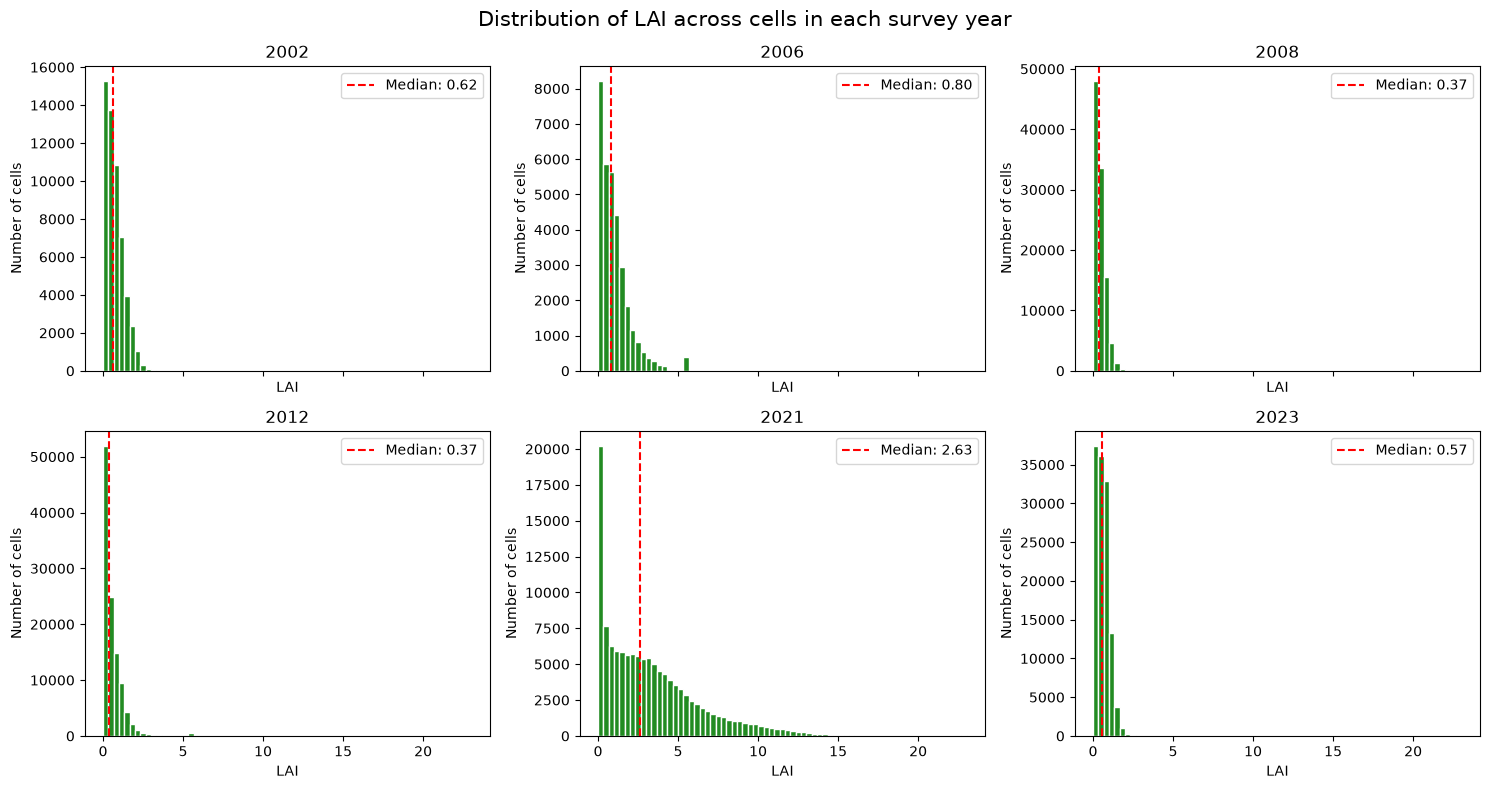

In [29]:
# Plot the LAI distribution separately for each LiDAR year.
years = sorted(attribute_table["LiDAR_year"].unique())

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8),
    sharex=True,
    sharey=False,
)

# Use the same bins so the six distributions can be compared fairly.
lai_bins = np.linspace(0, attribute_table["LAI"].max(), 70,)

for year, axis in zip(years, axes.flat):
    year_lai = attribute_table.loc[attribute_table["LiDAR_year"] == year, "LAI", ]

    axis.hist(year_lai, bins=lai_bins, color="forestgreen", edgecolor="white",)

    axis.set_title(str(year))
    axis.set_xlabel("LAI")
    axis.set_ylabel("Number of cells")
    axis.axvline(year_lai.median(), color="red", linestyle="--", label=f"Median: {year_lai.median():.2f}",)
    axis.legend()

fig.suptitle("Distribution of LAI across cells in each survey year", fontsize=15)
plt.tight_layout()
plt.show()


## 2.5 Category values and included forest areas

This counts how many different labels each category contains. It does not calculate averages for category codes. The year counts were already calculated in Section 1.4 and are reused here.

In [30]:
# Count unique values and missing rows in category columns.
category_columns = [
    "AOI", "block", "blk", "cpmt", "scpt",
    "display_id", "spis", "SPIS_RF", "code",
]

category_summary = pd.DataFrame({
    "unique_non_missing_values": attribute_table[category_columns].nunique(),
    "missing_rows": attribute_table[category_columns].isna().sum(),
})

category_summary

,unique_non_missing_values,missing_rows
AOI,1,0
block,2,0
blk,5,0
cpmt,237,0
scpt,26,0
display_id,2221,0
spis,40,118182
SPIS_RF,10,115542
code,10,115542


## Section 2 findings

**What one row represents**: One LiDAR measurement for one 20 m × 20 m plot polygon in one survey year. LiDAR measurements (columns 1–6) come from airborne point-cloud processing; forestry attributes (planting year, species, yield class, thinning dates) come from the **2025** sub-compartment database (SCDB) and are **static** — they do not change between survey years in this dataset even though the real forest did change over 21 years.

**Column groups and their roles for the PINN**:

| Group | Columns | Role |
|-------|---------|------|
| LiDAR measurements | CanopyCover, GapFraction, LAI, elev_percentile_95th | Raw observables — potential inputs or targets |
| Derived LiDAR | Top_Height, Vol | Allometric outputs from LiDAR — likely PINN targets |
| Survey context | AOI, LiDAR_year, area, identification | Needed for joining and splitting but not model features |
| SCDB attributes | spis, plyr, yldc, next_thin_, last_thinn, Age, block, blk, cpmt, scpt, display_id, SPIS_RF, code | Site context — useful but static (2025 vintage) and incomplete for ~21% of plots |

**Species composition**: Sitka spruce (`SS`) dominates at 46.6% of labelled records, followed by birch (5.4%), Scots pine (5.3%), and Norway spruce (4.7%). This matters for the PINN: if species strongly modulates growth rates, the ~21% with no species label represents a significant gap.

**Yield class**: Values are multiples of 2 (m³ ha⁻¹ yr⁻¹). The most common non-zero values are 24, 4, and 16. Zero (118,182 rows) means no yield class recorded, not "zero productivity".

**Critical concern — SCDB vintage**: All SCDB attributes reflect the 2025 database state. Planting years, species, and thinning dates may have been updated since 2002. Using 2025 species labels to train a model on 2002 LiDAR data could introduce anachronism if stands were replanted or species changed between surveys.

**Questions for domain experts:**
- Is a historical SCDB snapshot available for each survey year (2002, 2006, 2008, 2012, 2021, 2023)?
- For stands that were clearfelled and replanted between surveys, does the 2025 SCDB record the current species or the original species?

# 3. Exploring values and distributions

Section 1 already counted known unusual values. This section evaluates the **entire unfiltered table**, including every species, age, and available survey record. However, results are not pooled across years: every distribution, category chart, box plot, outlier rule, and validity check is calculated separately for each LiDAR year.

Each investigation therefore produces six panels or six sets of results. This is more thorough and prevents a large survey year or a year-specific processing method from hiding differences. Important additional checks are survey-to-survey scale changes, category imbalance, capped or rounded values, spatial or temporal clustering of extremes, unequal cell areas, and whether the patterns remain in the final Sitka spruce cohort.

## 3.1 Histograms of the main numerical variables

Each variable gets one figure containing six year-specific histograms. The six panels use the same bins and axes so their shapes can be compared fairly. The visible range is based on the full-table 0.1st–99.9th percentiles; this changes only the plot, not the data. Percentages are used because the years contain different numbers of rows. Age is plotted separately because invalid planting years require an explicit validity rule.

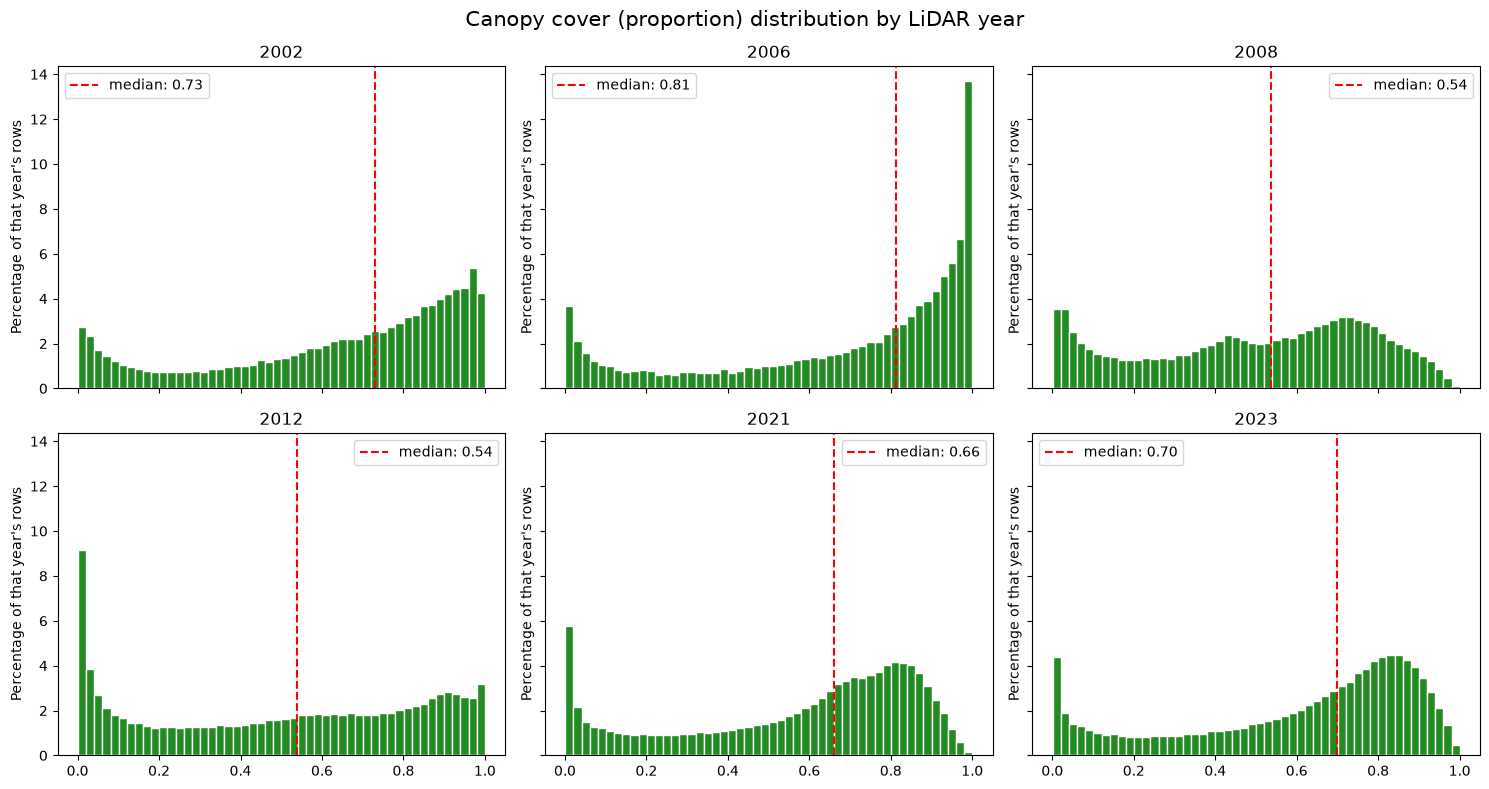

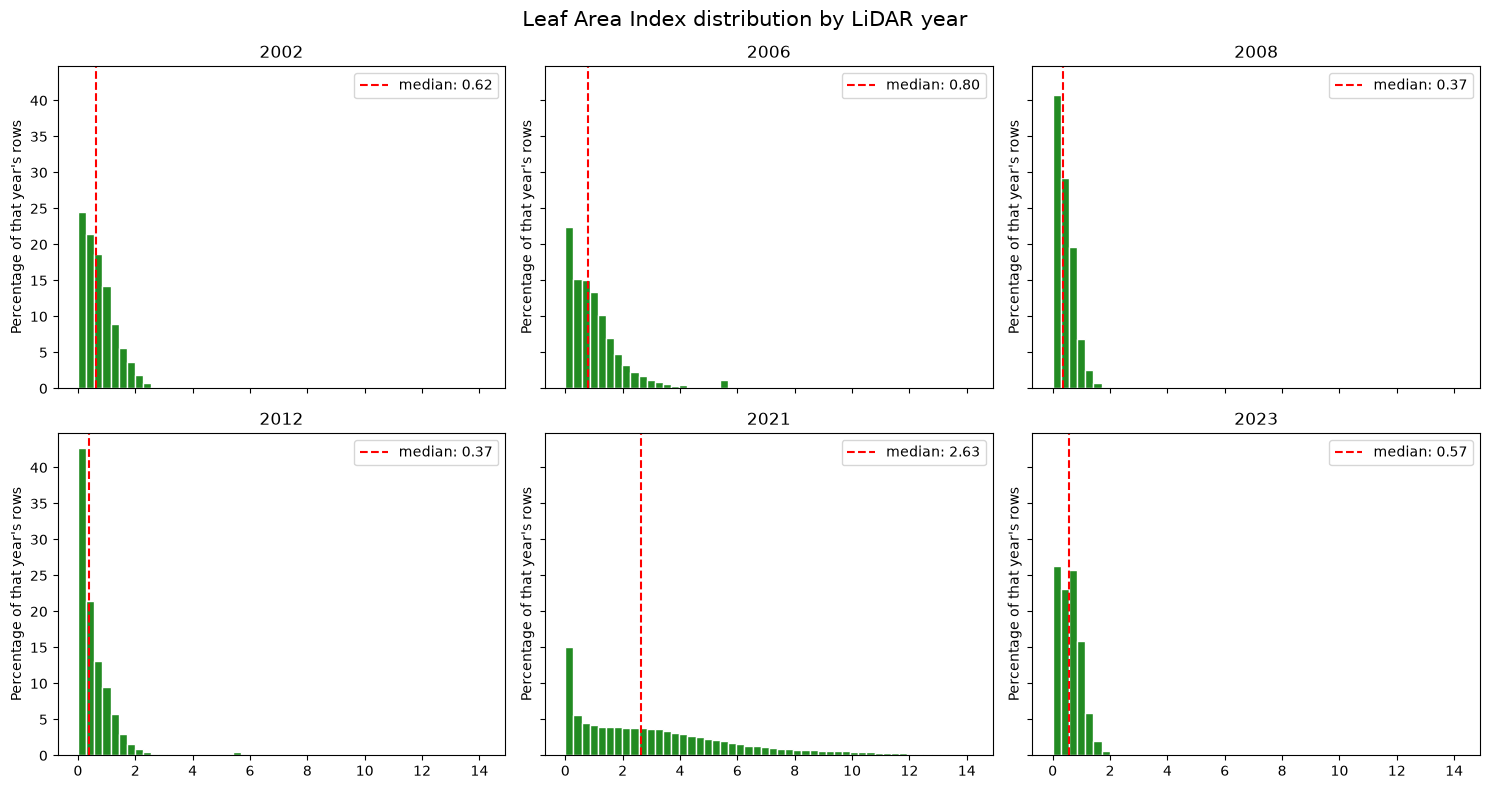

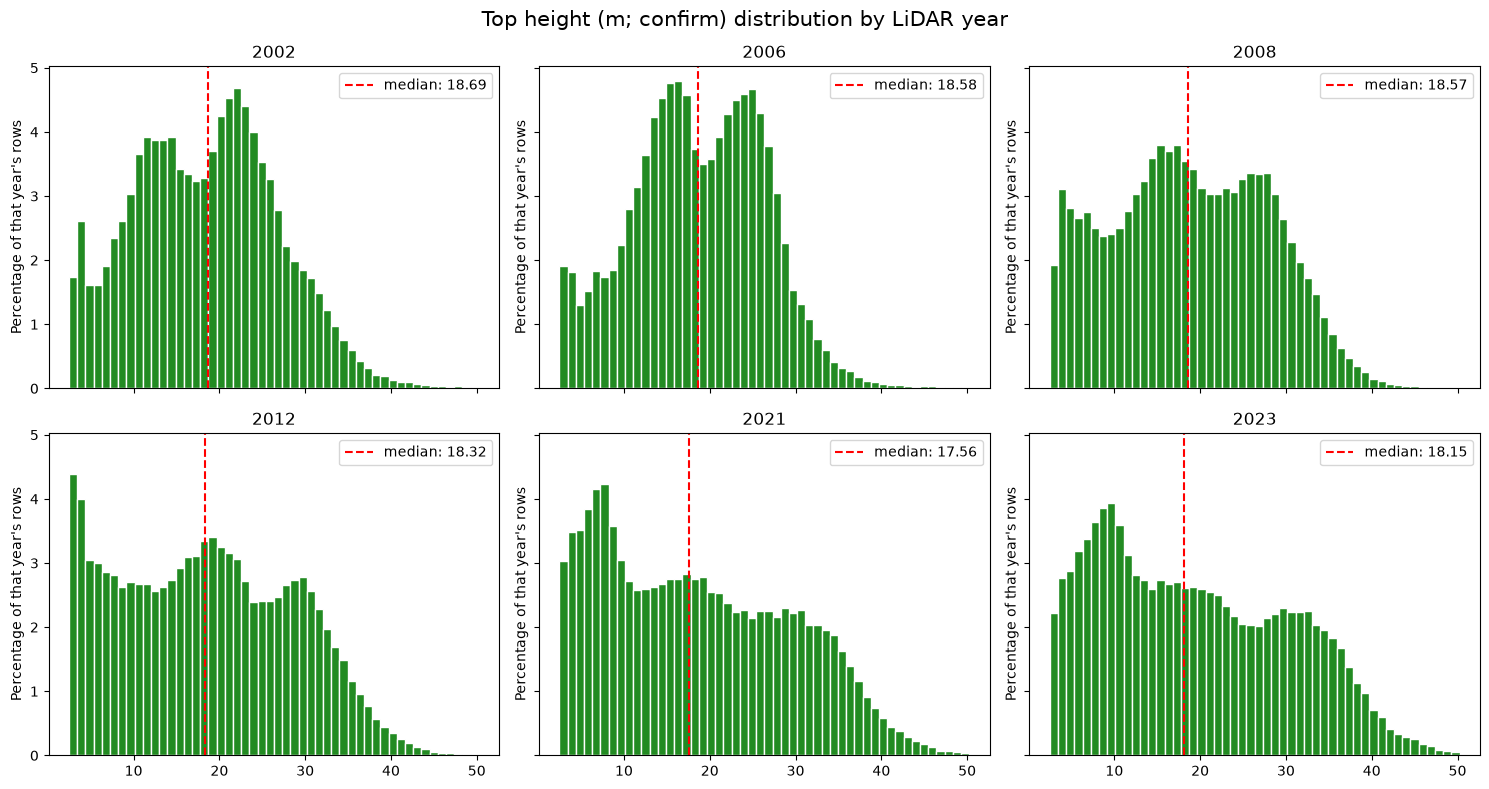

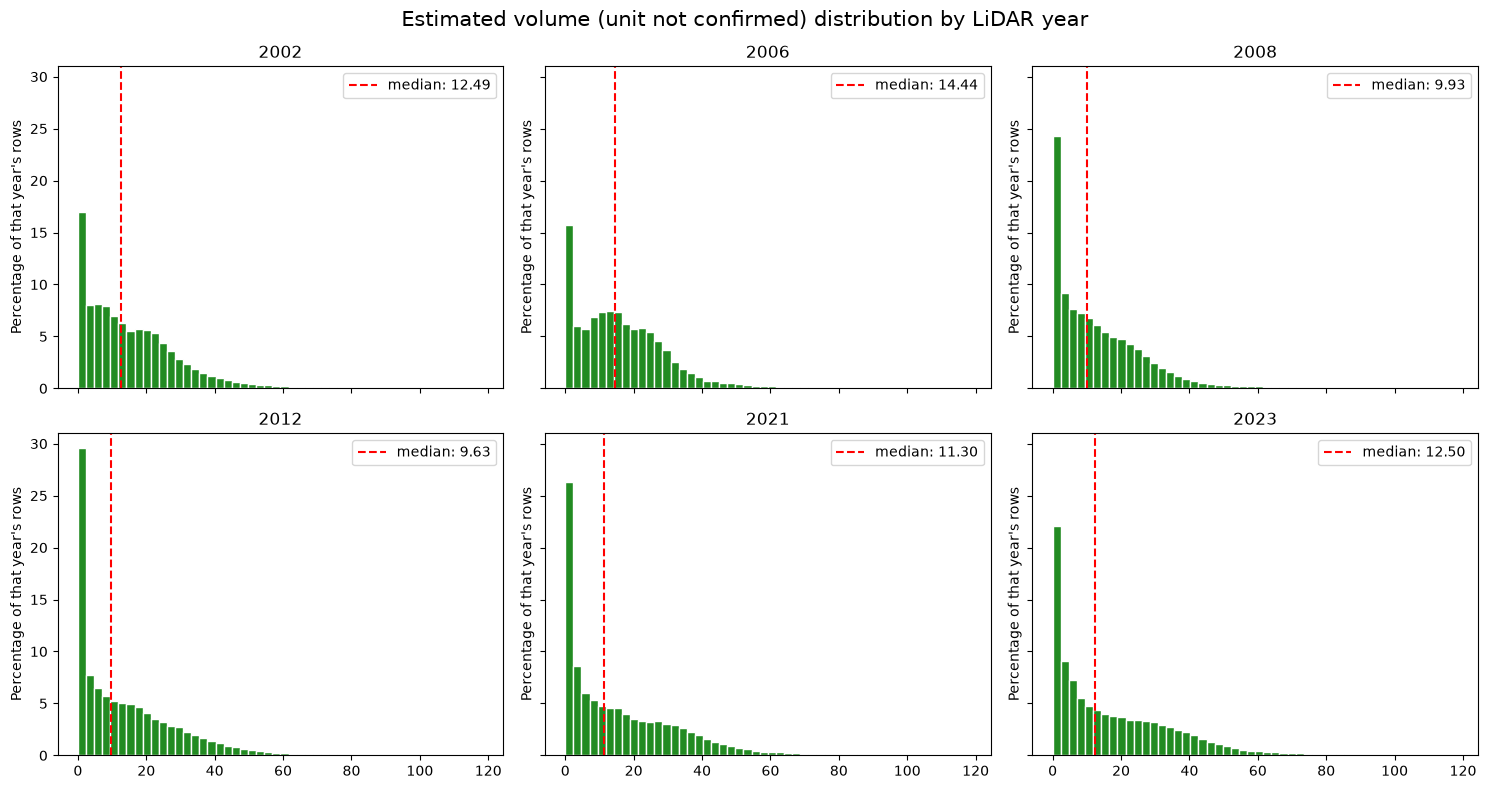

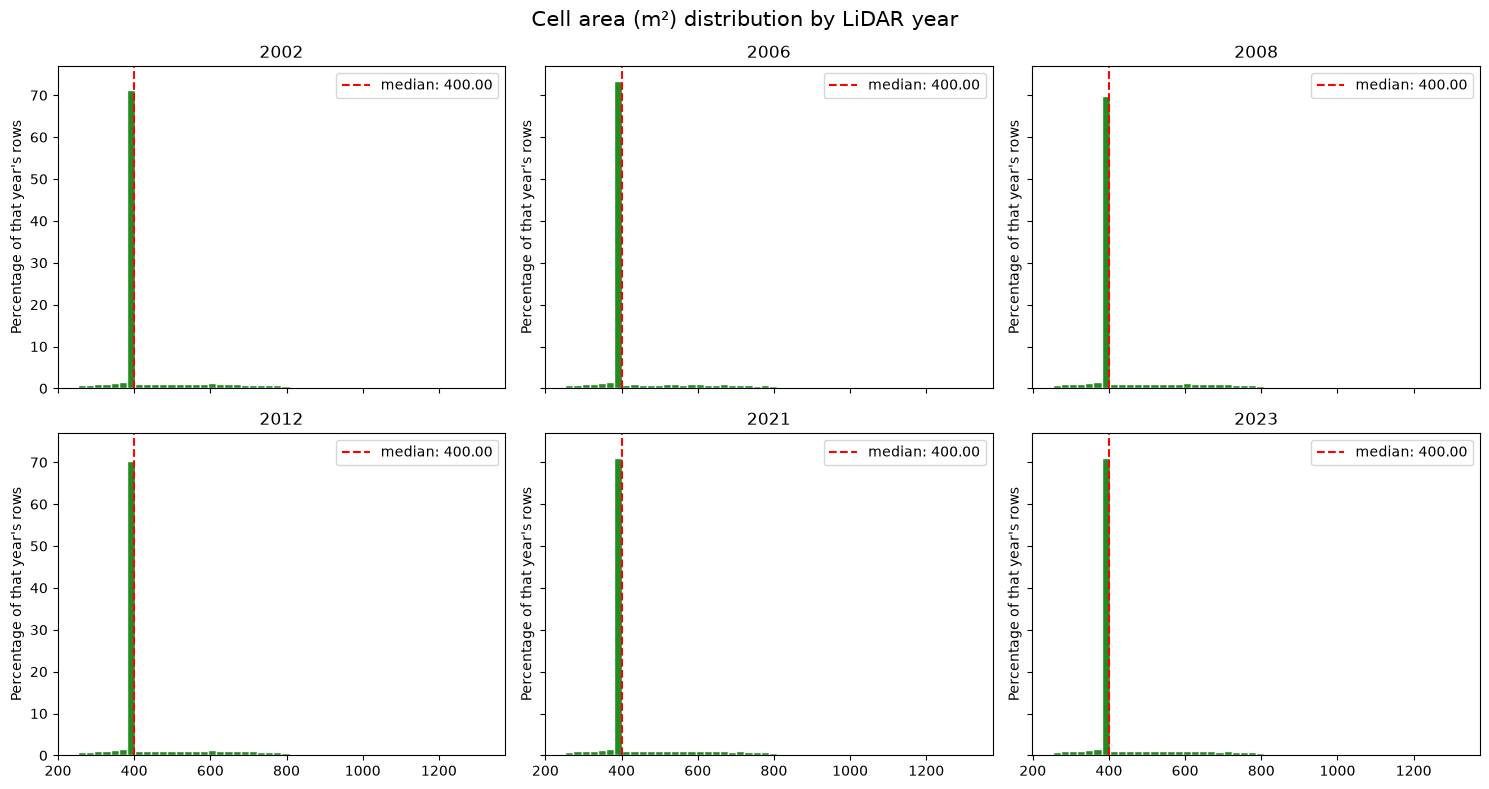

In [31]:
# Plot each numerical variable separately for all six survey years.
# Age is left out because many rows do not have a usable planting year.
histogram_variables = {
    "CanopyCover": "Canopy cover (proportion)",
    "LAI": "Leaf Area Index",
    "Top_Height": "Top height (m; confirm)",
    "Vol": "Estimated volume (unit not confirmed)",
    "area": "Cell area (m²)",
}

for variable, label in histogram_variables.items():
    all_values = attribute_table[variable].dropna()
    lower, upper = all_values.quantile([0.001, 0.999])
    common_bins = np.linspace(lower, upper, 51)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

    for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
        values = year_data[variable].dropna()
        visible = values.loc[values.between(lower, upper)]
        weights = np.ones(len(visible)) * 100 / len(values)
        axis.hist(visible, bins=common_bins, weights=weights,
                  color="forestgreen", edgecolor="white")
        axis.axvline(values.median(), color="red", linestyle="--",
                     label=f"median: {values.median():.2f}")
        axis.set_title(str(year))
        axis.set_ylabel("Percentage of that year's rows")
        axis.legend()

    fig.suptitle(f"{label} distribution by LiDAR year", fontsize=15)
    plt.tight_layout()

    # Save as a high-resolution PNG
    output_path = output_directory / f"{variable}_distribution_by_year.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    
    plt.show()

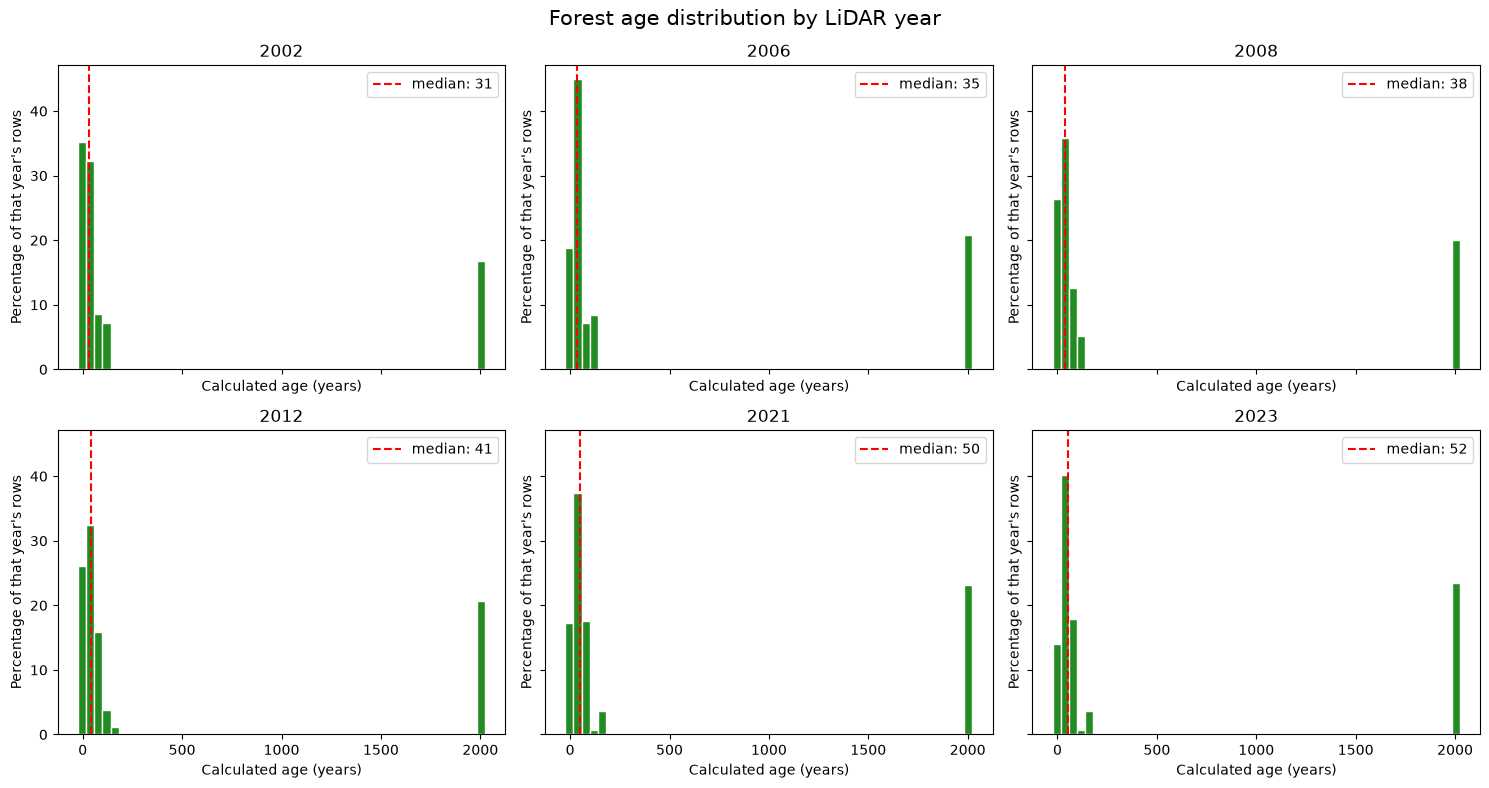

In [32]:
# Plot the full calculated Age distribution without removing any values.
# Age equals LiDAR year minus planting year. Planting year zero therefore
# creates very large ages equal to the survey year.
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
all_ages = attribute_table["Age"].dropna()
age_bins = np.linspace(all_ages.min(), all_ages.max(), 51)

for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
    ages = year_data["Age"].dropna()
    
    # Convert counts to percentages because survey years contain different
    # numbers of rows. Every non-missing calculated age is included.
    weights = np.ones(len(ages)) * 100 / len(ages)
    axis.hist(ages, bins=age_bins, weights=weights,
              color="forestgreen", edgecolor="white")
    axis.axvline(ages.median(), color="red", linestyle="--",
                 label=f"median: {ages.median():.0f}")
    axis.set_title(str(year))
    axis.set_xlabel("Calculated age (years)")
    axis.set_ylabel("Percentage of that year's rows")
    axis.legend()

fig.suptitle("Forest age distribution by LiDAR year", fontsize=15)
plt.tight_layout()
fig.savefig(output_directory / "age_distribution_by_year.png",
            dpi=300, bbox_inches="tight")
plt.show()

### Age-distribution interpretation

This figure deliberately includes the complete calculated age range. The main forest-age values occupy the lower part of the x-axis, while a separate group appears near 2002–2023 years. Those very large values are produced when planting year is recorded as zero: `Age = LiDAR_year - 0`. They are unavailable planting information expressed through the calculation, not biologically possible forest ages.

Negative ages are also retained. They indicate that the linked planting year is later than the LiDAR survey and may represent later replanting rather than an erroneous date. Showing the full range makes both data limitations visible, although it compresses the plausible forest-age distribution near the left side of each panel.

The planting information comes from the 2025 sub-compartment database. Consequently, the histogram describes age calculated from the currently linked planting year; it may not represent the stand that occupied a plot during an earlier LiDAR survey.

### Provisional age cleaning

The next check applies the likely age-cleaning rule: planting year must be greater than zero and calculated age must be between 0 and 200 years. This is provisional because later planting dates may represent genuine replanting rather than erroneous records.

,total_rows,retained_rows,excluded_rows,excluded_percentage
LiDAR_year,,,,
2002,54857,38056,16801,30.63
2006,32745,22585,10160,31.03
2008,103412,71420,31992,30.94
2012,110425,79638,30787,27.88
2021,124695,93200,31495,25.26
2023,124814,94593,30221,24.21


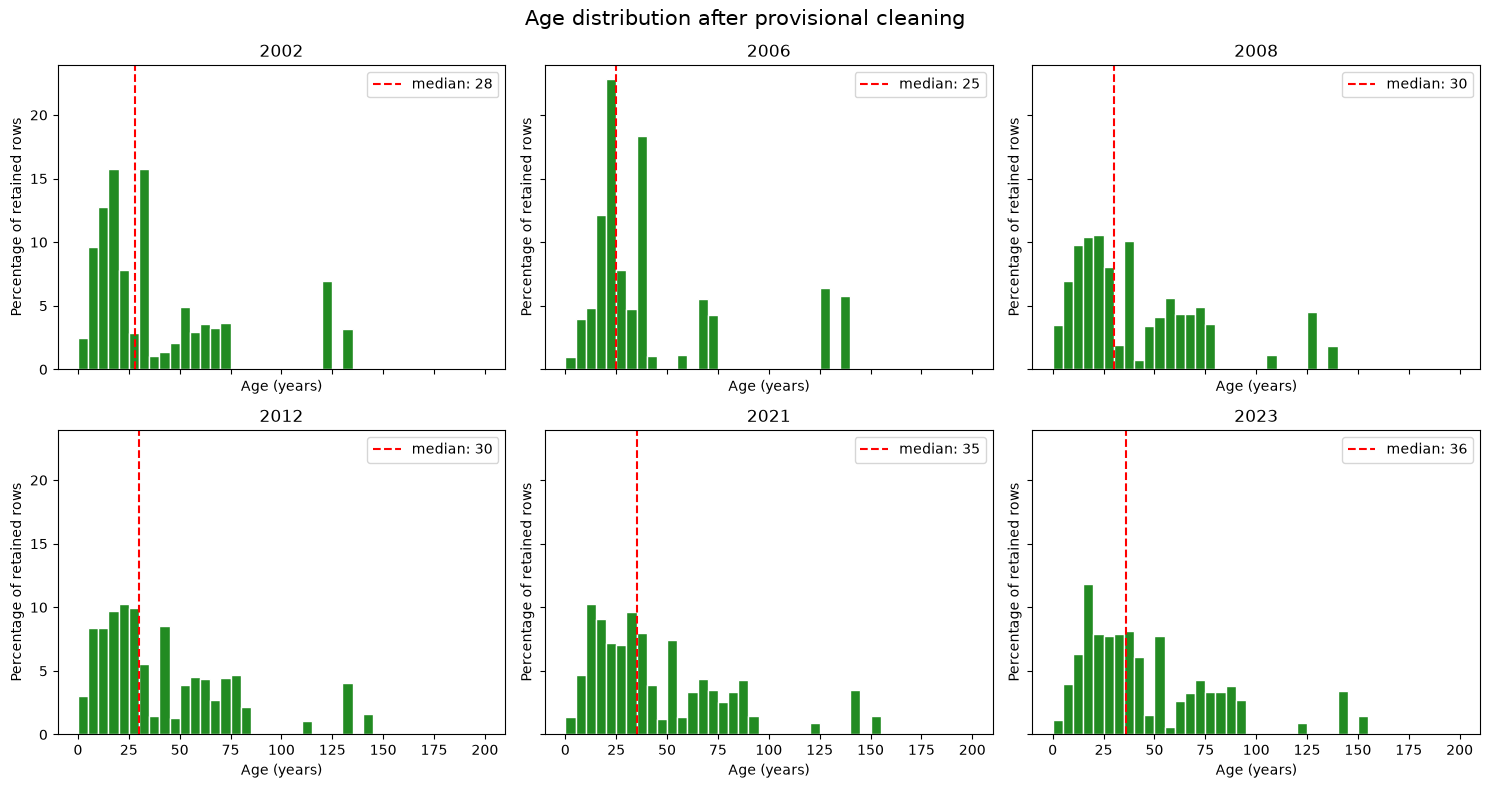

In [33]:
# Define the provisional age-cleaning rule once.
valid_age = attribute_table["plyr"].gt(0) & attribute_table["Age"].between(0, 200)

# Count how many rows would be retained and excluded in each survey year.
age_cleaning_summary = (
    attribute_table.assign(valid_age=valid_age)
    .groupby("LiDAR_year")
    .agg(total_rows=("Age", "size"), retained_rows=("valid_age", "sum"))
)
age_cleaning_summary["excluded_rows"] = (
    age_cleaning_summary["total_rows"] - age_cleaning_summary["retained_rows"]
)
age_cleaning_summary["excluded_percentage"] = (
    age_cleaning_summary["excluded_rows"]
    .div(age_cleaning_summary["total_rows"])
    .mul(100).round(2)
)
display(age_cleaning_summary)

# Plot the retained age values with common five-year bins.
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
age_bins = np.arange(0, 205, 5)

for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
    ages = year_data.loc[
        year_data["plyr"].gt(0) & year_data["Age"].between(0, 200),
        "Age",
    ]
    weights = np.ones(len(ages)) * 100 / len(ages)
    axis.hist(ages, bins=age_bins, weights=weights,
              color="forestgreen", edgecolor="white")
    axis.axvline(ages.median(), color="red", linestyle="--",
                 label=f"median: {ages.median():.0f}")
    axis.set_title(str(year))
    axis.set_xlabel("Age (years)")
    axis.set_ylabel("Percentage of retained rows")
    axis.legend()

fig.suptitle("Age distribution after provisional cleaning", fontsize=15)
plt.tight_layout()
fig.savefig(output_directory / "cleaned_age_distribution_by_year.png",
            dpi=300, bbox_inches="tight")
plt.show()

### Effect of provisional age cleaning

The rule excludes 16,801 rows (30.63%) in 2002, 10,160 (31.03%) in 2006, 31,992 (30.94%) in 2008, 30,787 (27.88%) in 2012, 31,495 (25.26%) in 2021, and 30,221 (24.21%) in 2023.

The cleaned histograms make the plausible planting cohorts visible, but the exclusion is substantial in every year. These rows should not be deleted from the master dataset: age should be set to unavailable for age-dependent analysis, while the same plots may remain usable for analyses that do not require age.

## 3.2 Bar charts for important categories

Each category receives six year-specific panels. Within each year, every `identification` is counted once. Species, yield class, and block are static 2025 attributes, so differences between years describe which plots were covered by each survey; they do not show attributes changing through time. Percentages are used because survey sizes differ.

In [34]:
for column in ["spis"]:
    print(f"\n{column}")
    display(
        attribute_table[column]
        .value_counts(dropna=False)
        .head(20)
    )


spis


spis
SS     256655
NaN    118182
BI      29824
SP      29139
NS      25876
OK      25249
MB      23226
DF       7735
LP       5487
JL       5029
EL       4517
HL       4154
MC       2787
SOK      2105
NF       1567
CAR      1512
BE       1430
ASP      1022
PBI       832
RC        800
Name: count, dtype: int64

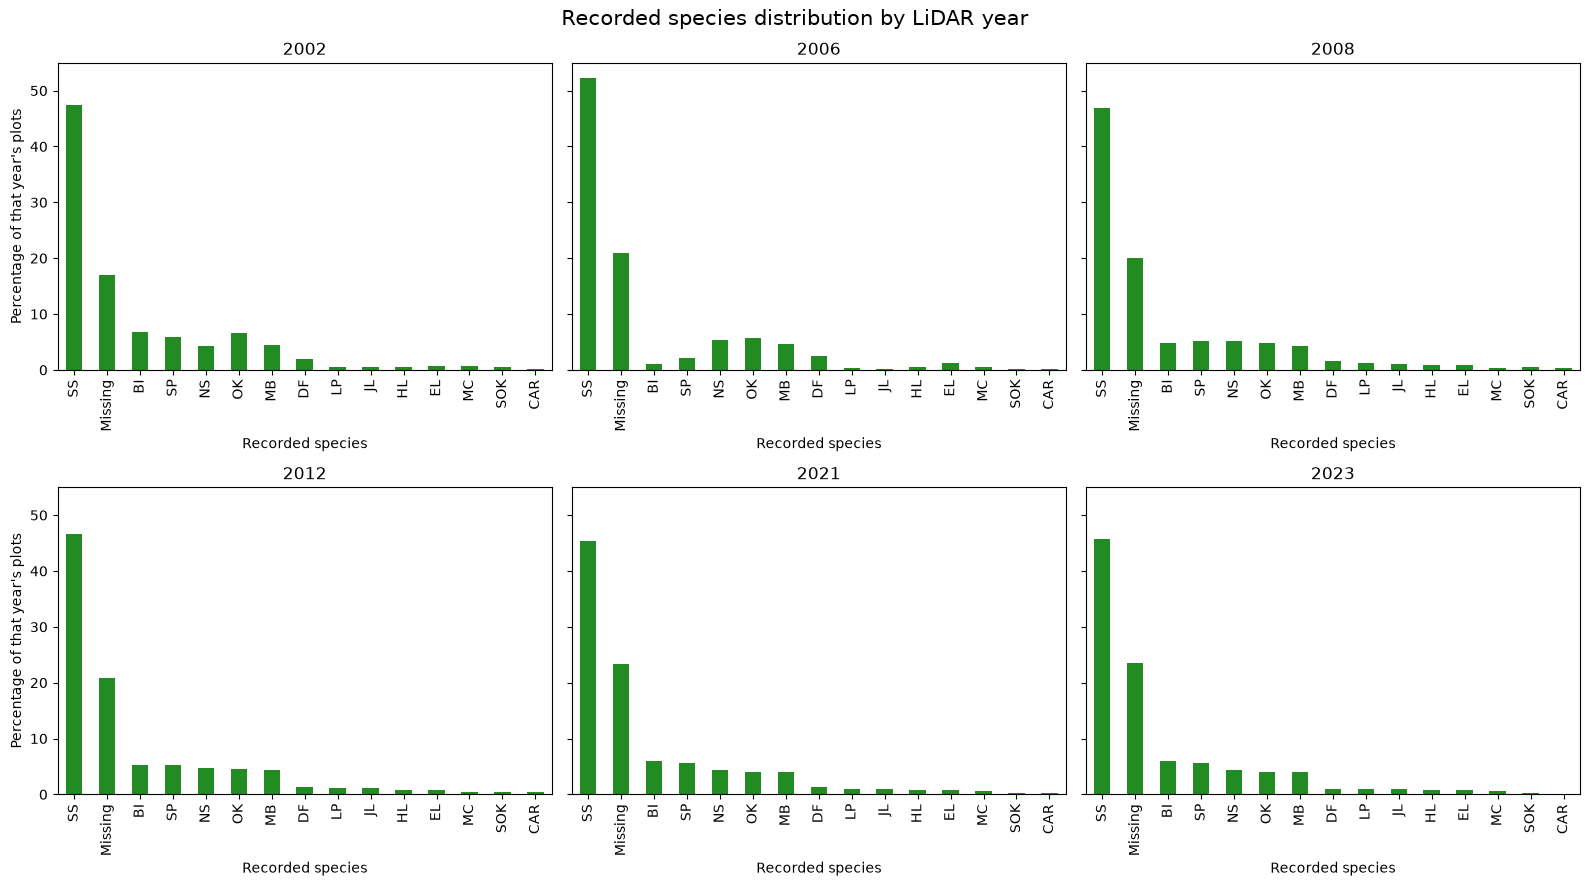

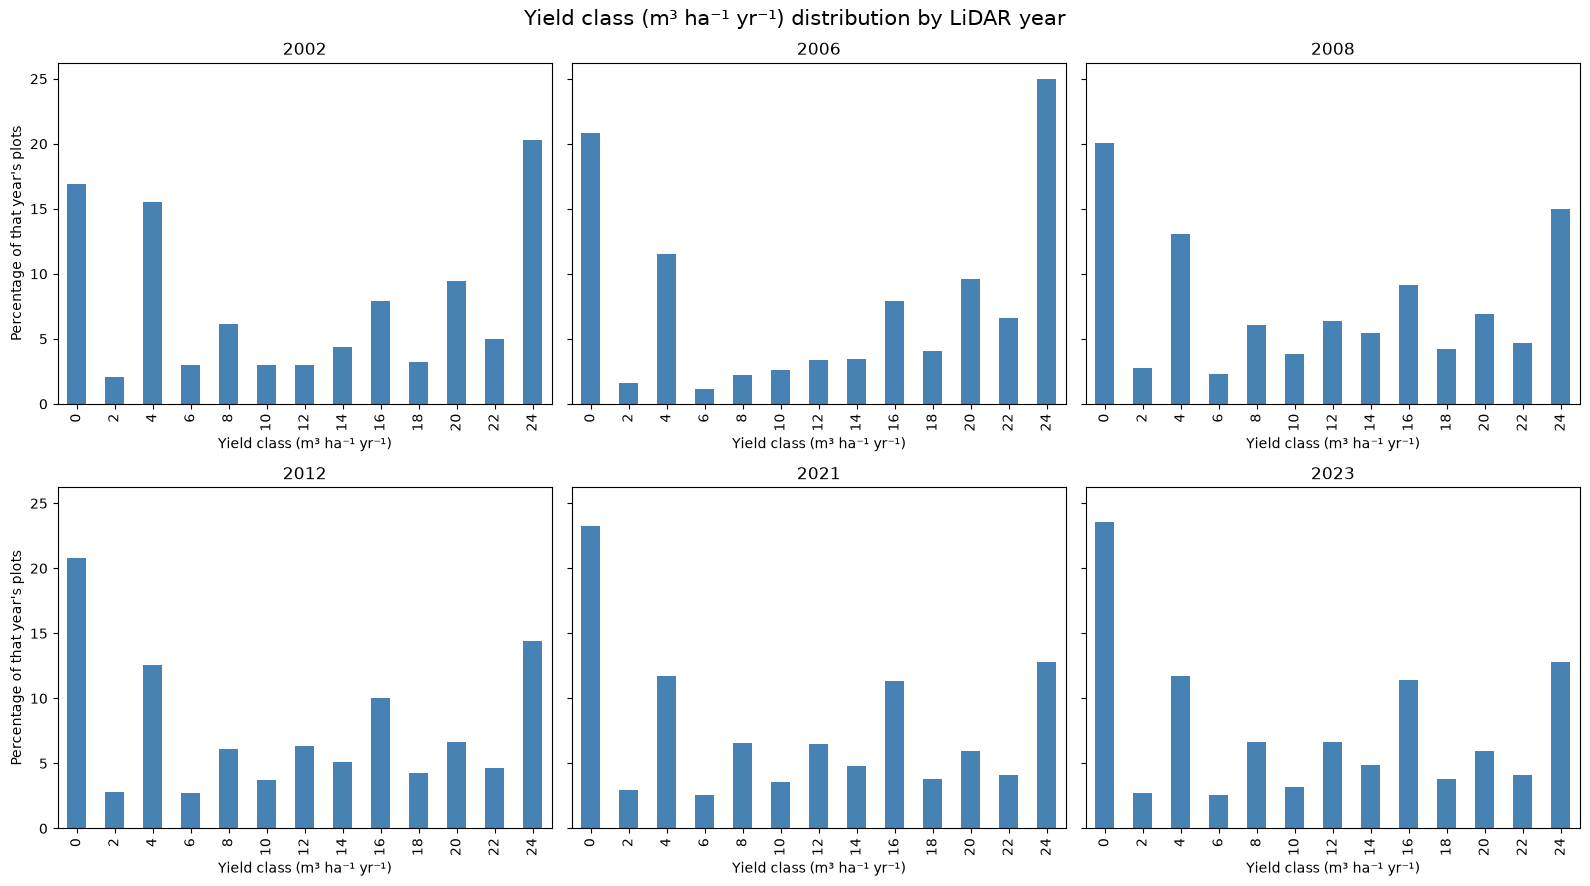

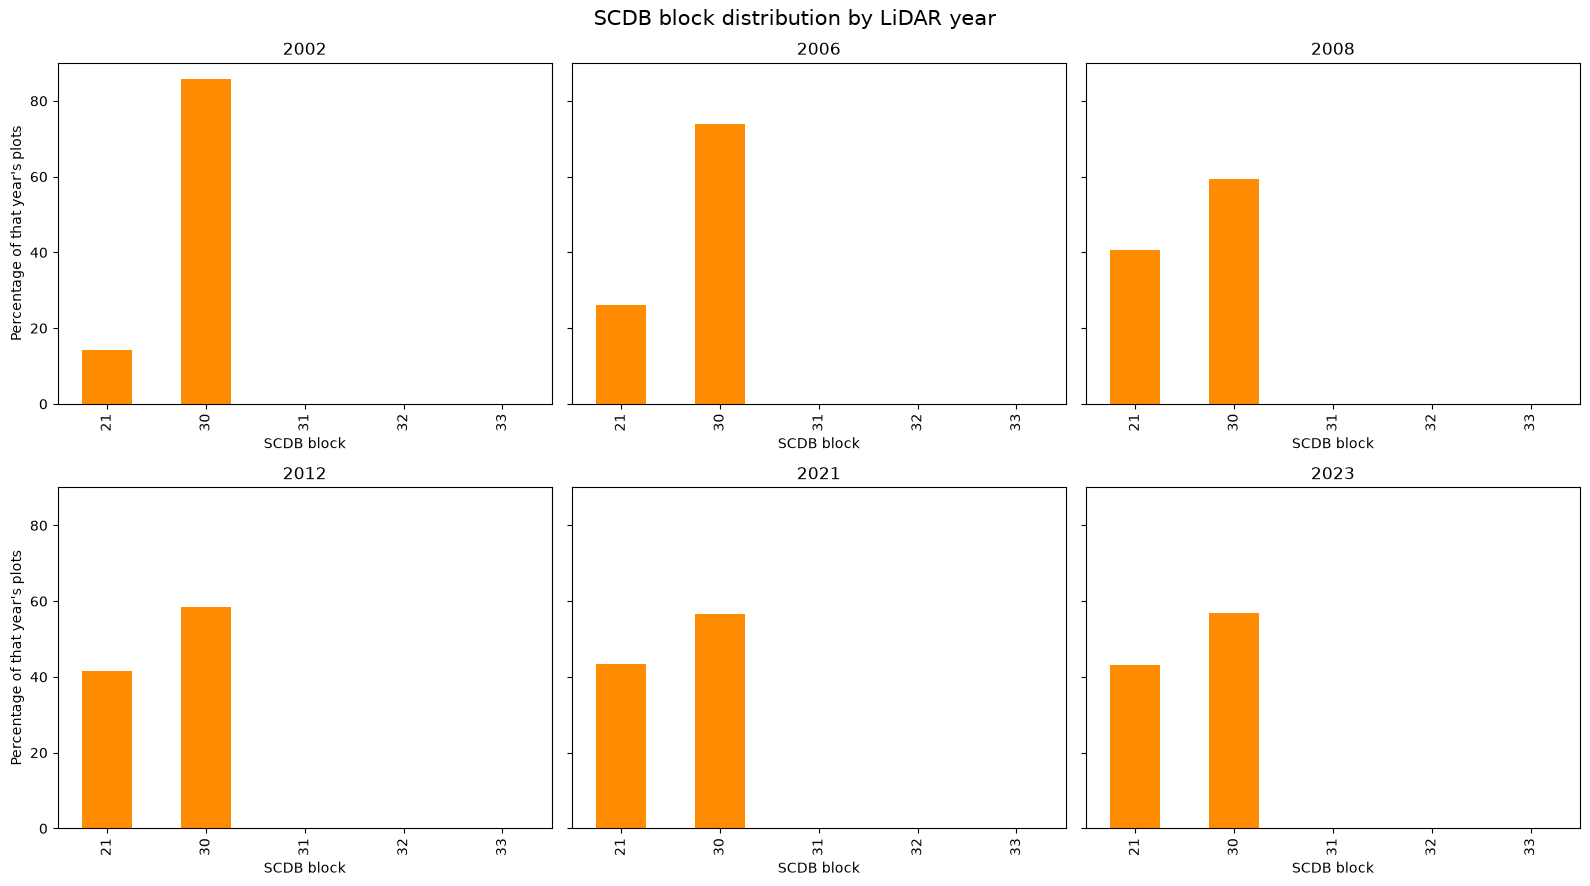

In [35]:
# Use the same category levels in all six panels.
one_row_per_plot = attribute_table.drop_duplicates("identification")
species_levels = (
    one_row_per_plot["spis"].fillna("Missing").value_counts().head(15).index
)
yield_class_levels = sorted(attribute_table["yldc"].unique())
block_levels = sorted(attribute_table["blk"].unique())

category_plots = {
    "spis": (species_levels, "Recorded species", "forestgreen"),
    "yldc": (yield_class_levels, "Yield class (m³ ha⁻¹ yr⁻¹)", "steelblue"),
    "blk": (block_levels, "SCDB block", "darkorange"),
}

for column, (levels, label, colour) in category_plots.items():
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

    for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
        plots_in_year = year_data.drop_duplicates("identification")
        values = plots_in_year[column]
        if column == "spis":
            values = values.fillna("Missing")
        percentages = (
            values.value_counts().reindex(levels, fill_value=0)
            / len(plots_in_year) * 100
        )
        percentages.plot.bar(ax=axis, color=colour)
        axis.set_title(str(year))
        axis.set_xlabel(label)
        axis.set_ylabel("Percentage of that year's plots")
        axis.tick_params(axis="x", labelrotation=90)

    fig.suptitle(f"{label} distribution by LiDAR year", fontsize=15)
    plt.tight_layout()
    plt.show()

## 3.3 Box plots and statistical outliers by survey year

Each measurement receives six year-specific box plots with a shared vertical scale. Individual outlier points are hidden to keep the boxes readable. The table then calculates separate 1.5 × IQR limits for every variable and year. Statistical outliers may be genuine forest conditions and are not automatically removed.

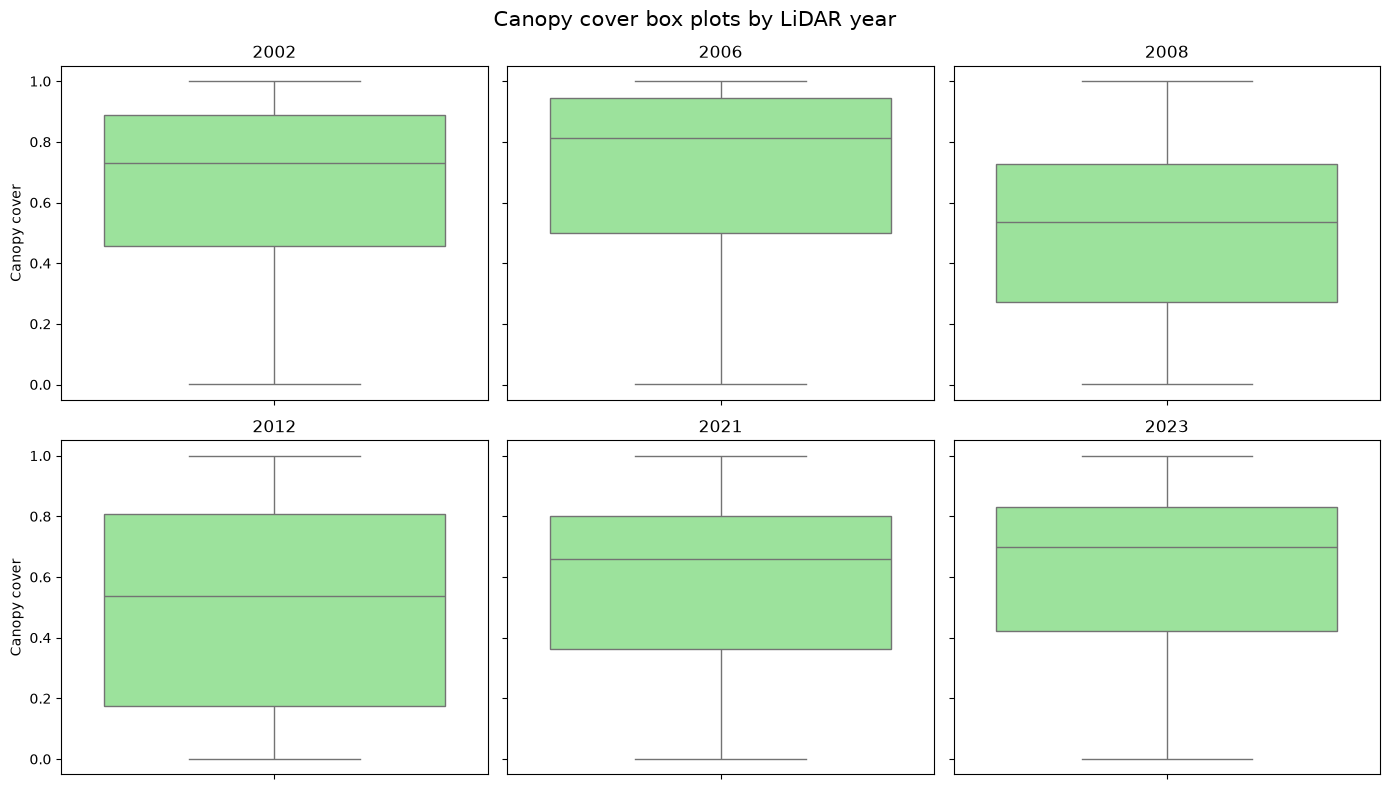

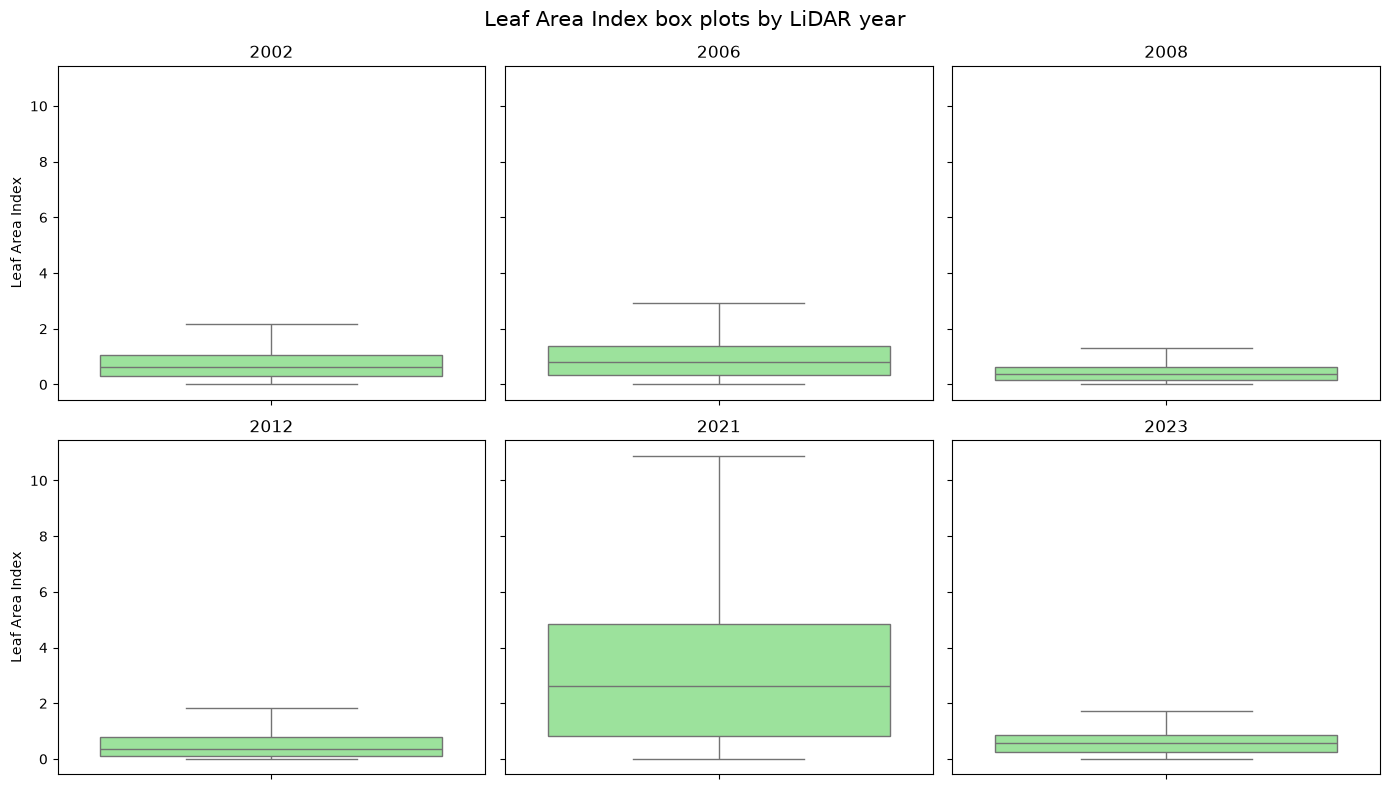

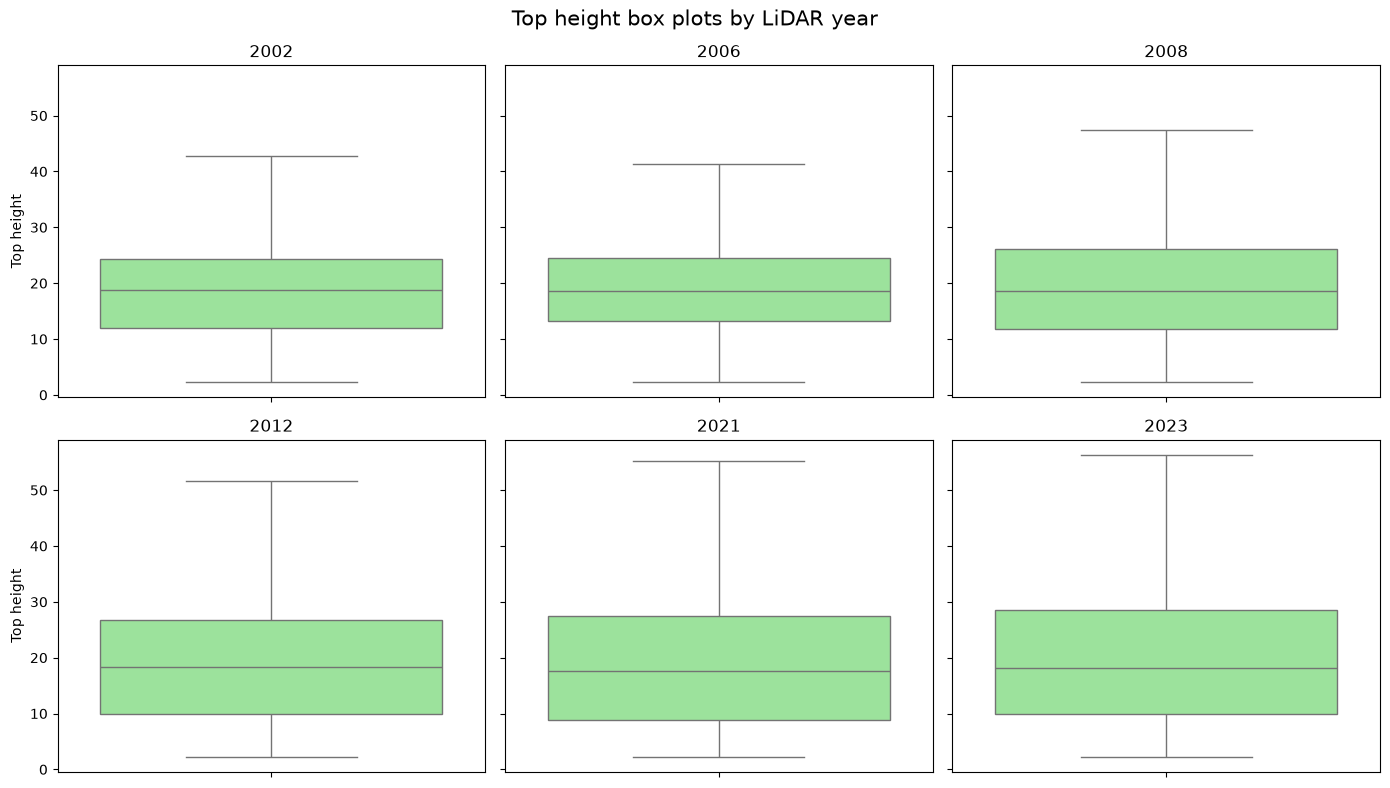

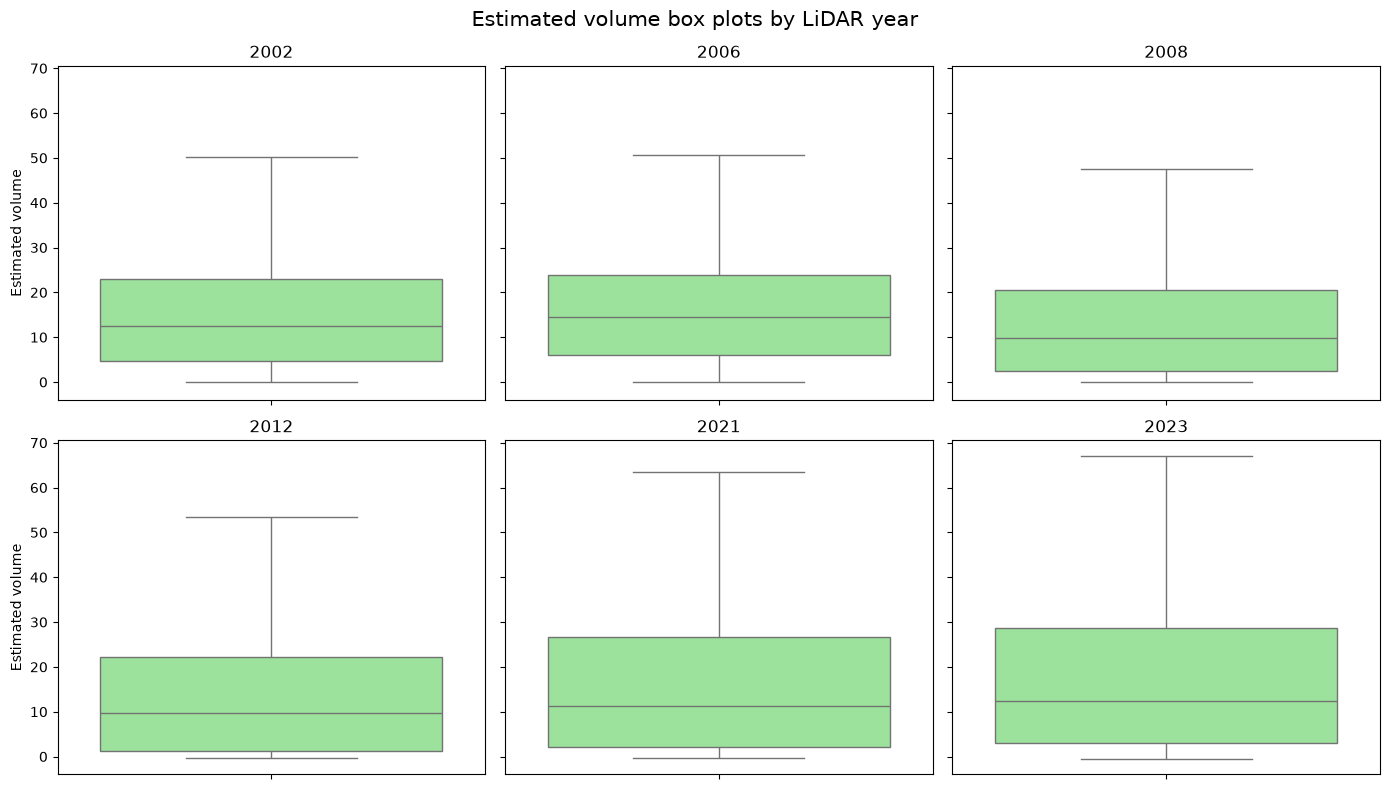

,LiDAR_year,variable,lower_limit,upper_limit,rows_outside,percentage_outside
0,2002,CanopyCover,-0.191044,1.535865,0,0.00
1,2002,LAI,-0.842243,2.180597,878,1.60
2,2002,Top_Height,-6.426652,42.711017,244,0.44
3,2002,Vol,-22.715716,50.239882,1449,2.64
4,2006,CanopyCover,-0.165910,1.609303,0,0.00
5,2006,LAI,-1.233027,2.937545,1406,4.29
6,2006,Top_Height,-3.601061,41.335616,106,0.32
7,2006,Vol,-20.630970,50.644881,731,2.23
8,2008,CanopyCover,-0.407887,1.408106,0,0.00
9,2008,LAI,-0.549655,1.322451,1644,1.59


In [36]:
# Compare four main measurements between survey years.
boxplot_variables = {
    "CanopyCover": "Canopy cover",
    "LAI": "Leaf Area Index",
    "Top_Height": "Top height",
    "Vol": "Estimated volume",
}

for variable, label in boxplot_variables.items():
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
    for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
        sns.boxplot(data=year_data, y=variable, showfliers=False,
                    color="lightgreen", ax=axis)
        axis.set_title(str(year))
        axis.set_xlabel("")
        axis.set_ylabel(label)
    fig.suptitle(f"{label} box plots by LiDAR year", fontsize=15)
    plt.tight_layout()
    plt.show()

# Count values outside the box-plot limits.
iqr_results = []
for year, year_data in data_by_year.items():
    for variable in boxplot_variables:
        q1, q3 = year_data[variable].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outside = ~year_data[variable].between(lower, upper)
        iqr_results.append({
            "LiDAR_year": year, "variable": variable,
            "lower_limit": lower, "upper_limit": upper,
            "rows_outside": outside.sum(),
            "percentage_outside": round(outside.mean() * 100, 2),
        })

iqr_outlier_summary = pd.DataFrame(iqr_results)
iqr_outlier_summary

## 3.4 Impossible, extreme, and capped values

Physical bounds, future dates, extreme measurements, and LAI capping are counted separately for all six years. The exact extreme-height and volume records are also returned for mapping or raw-LiDAR checking.

In [37]:
# Count values that violate simple physical or coding rules in each year.
domain_checks_by_year = pd.DataFrame({
    year: {
        "CanopyCover outside 0 to 1": (~d["CanopyCover"].between(0, 1)).sum(),
        "GapFraction outside 0 to 1": (~d["GapFraction"].between(0, 1)).sum(),
        "negative LAI": d["LAI"].lt(0).sum(),
        "Top_Height at or below zero": d["Top_Height"].le(0).sum(),
        "area at or below zero": d["area"].le(0).sum(),
        "planting year after 2025": d["plyr"].gt(2025).sum(),
        "last thinning after 2025": d["last_thinn"].gt(2025).sum(),
        "Top_Height above 150 m": d["Top_Height"].gt(150).sum(),
        "Vol above 1000": d["Vol"].gt(1000).sum(),
    }
    for year, d in data_by_year.items()
}).T

# Check whether LAI piles up at 5.5 or extends beyond it.
lai_cap_summary = (
    attribute_table.assign(
        LAI_at_5_5=np.isclose(attribute_table["LAI"], 5.5),
        LAI_above_5_5=attribute_table["LAI"].gt(5.5),
    )
    .groupby("LiDAR_year")
    .agg(
        rows=("LAI", "size"),
        rows_at_5_5=("LAI_at_5_5", "sum"),
        rows_above_5_5=("LAI_above_5_5", "sum"),
        maximum_LAI=("LAI", "max"),
    )
)

extreme_measurement_rows = (
    attribute_table.loc[
        attribute_table["Top_Height"].gt(150) | attribute_table["Vol"].gt(1000),
        ["identification", "LiDAR_year", "display_id", "spis",
         "CanopyCover", "LAI", "Top_Height", "Vol"],
    ]
    .sort_values(["identification", "LiDAR_year"])
)

display(domain_checks_by_year)
display(lai_cap_summary)
extreme_measurement_rows

,CanopyCover outside 0 to 1,GapFraction outside 0 to 1,negative LAI,Top_Height at or below zero,area at or below zero,planting year after 2025,last thinning after 2025,Top_Height above 150 m,Vol above 1000
2002,0,0,0,0,0,53,477,1,1
2006,0,0,0,0,0,0,477,0,0
2008,0,0,0,0,0,53,477,0,0
2012,0,0,0,0,0,53,477,2,0
2021,0,0,0,0,0,53,477,2,1
2023,0,0,0,0,0,40,477,1,0


,rows,rows_at_5_5,rows_above_5_5,maximum_LAI
LiDAR_year,,,,
2002,54857,41,0,5.500000
2006,32745,404,0,5.500000
2008,103412,22,0,5.500000
2012,110425,574,0,5.500000
2021,124695,0,25050,23.024964
2023,124814,5,0,5.500000


,identification,LiDAR_year,display_id,spis,CanopyCover,LAI,Top_Height,Vol
264090,235346,2012,701 30 2194 E,LP,0.552632,0.384268,307.176276,810.696472
383710,235346,2021,701 30 2194 E,LP,0.796140,3.407355,340.670316,1370.250722
508125,235346,2023,701 30 2194 E,LP,0.821182,0.822347,152.876694,409.845988
41096,366560,2002,701 30 2176 S,SS,0.643592,0.492858,248.795986,1152.403564
295110,366560,2012,701 30 2176 S,SS,0.404312,0.247479,216.838541,585.436377
417877,366560,2021,701 30 2176 S,SS,0.304674,0.613842,244.975687,532.659429


## Section 3 findings

**Top height**: Medians are stable across years (17.56–18.69 m), which is partly a selection effect — each survey covers a different subset of the forest. Six records exceed 100 m (max 340.67 m), which is physically impossible. These are likely isolated LiDAR artefacts (tall trees misclassified as ground, communication masts, or processing errors) and should be flagged for spatial inspection.

**Canopy cover**: Drops sharply from 0.813 (2006) to 0.537 (2008), coinciding with the survey expansion. The 2008 survey added ~71,000 new plots, many of which are likely younger or more open stands that had not been scanned before. This is a **coverage-composition effect**, not necessarily a real forest-wide canopy decline.

**Volume**: 15,455 records have negative Vol (up to −0.54). These arise near the zero boundary of the allometric model and should be clipped to 0. Two records exceed Vol = 1,000 (max 1,370.25) — these are extreme and should be spatially inspected.

**LAI**: The 2021 anomaly (median 2.635, max 23.025 vs max 5.5 in all other years) is confirmed across the full distribution. The histograms show this as a clear scale shift in 2021. This is a processing artefact, not biology.

**Age distribution** (from the age-categories cell above):
- **399,492 rows** have valid ages in the range 0–200 yr (72.5% of all records).
- **117,882 rows** have `Age = LiDAR_year` (plyr=0 artefact — no usable age).
- **33,570 rows** have negative Age (SCDB planting year recorded as after the scan date).
- **4 rows** have Age > 200 that are not the plyr=0 artefact — likely data entry errors.

**Area**: Nominal cell area is 400 m² (20 m × 20 m), but cells near survey boundaries have smaller areas (min ~250 m²) and some are larger (max ~1,579 m²). Area is not a useful model feature but should be recorded for spatial normalisation.

**Questions for domain experts:**
- Do the 6 records with Top_Height > 100 m correspond to known non-forest objects (e.g. radio masts, water towers) that should be masked in the LiDAR processing?
- Is there a forest operations log for Aberfoyle that records clearfelling and thinning events by year? This would allow the canopy cover and volume drops to be validated against actual operations.

# 4. Compare variables

This section checks whether the main measurements move together, compares groups, and summarises change where plots were measured again. A high correlation alone is not enough reason to combine two variables.

The correlation matrix excludes variables that would be misleading to treat as independent continuous measurements:

- `GapFraction = 1 - CanopyCover`, so it contains the same information in reverse.
- `Top_Height = 1.1 × elev_percentile_95th`, so only top height is retained.
- `identification`, `block`, `blk`, and `cpmt` are identifiers or category codes.
- `LiDAR_year`, planting year, and thinning years are dates.
- Yield class (`yldc`) is included cautiously, with placeholder zeros treated as missing.

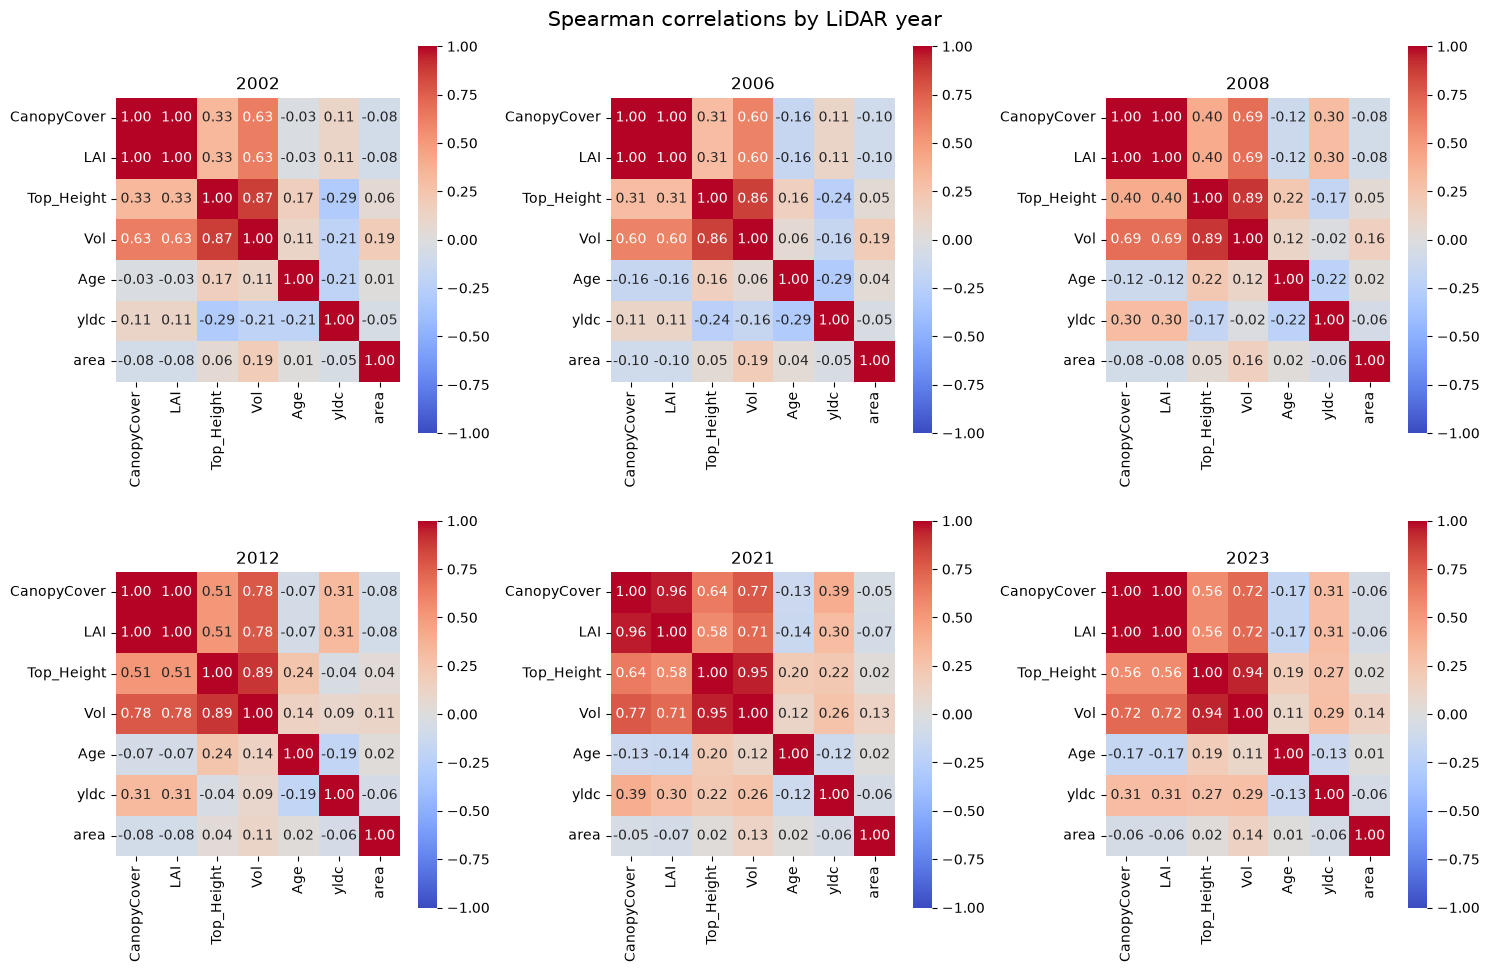

In [38]:
# Compare the main continuous forest measurements and useful context variables.
# IDs, dates, category codes, and exact derived copies are excluded.
correlation_variables = ["CanopyCover","LAI","Top_Height","Vol","Age","yldc","area",]

# Make one heatmap per year so a relationship is not created simply by
# combining surveys with different measurement scales or coverage.
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
    correlation_data = year_data[correlation_variables].copy()

    # Yield class zero means unavailable, so it must not be treated as
    # a genuine low yield class in this calculation.
    correlation_data["yldc"] = correlation_data["yldc"].replace(0, np.nan)

    # Spearman correlation equals Pearson correlation of ranked values.
    # Ranking reduces the influence of extreme values and avoids requiring SciPy.
    correlation = correlation_data.rank().corr()
    sns.heatmap(correlation, vmin=-1, vmax=1, center=0, cmap="coolwarm",
                annot=True, fmt=".2f", square=True, ax=axis)
    axis.set_title(str(year))

fig.suptitle("Spearman correlations by LiDAR year", fontsize=15)
plt.tight_layout()
fig.savefig(output_directory / "correlations_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.1 Correlation interpretation

Correlation coefficients are computed per year after excluding zero yield-class and plyr=0 Age values.

- **Top height and volume** have the strongest consistent relationship across years (r = 0.76–0.86). They are closely related but not interchangeable: top height is a direct canopy structural measurement, while volume is an allometric estimate incorporating species and density assumptions. For PINN modelling, they would typically be treated as separate outputs.
- **Canopy cover and LAI** are strongly correlated in five of six years (r = 0.72–0.91). In these years, LAI provides little information beyond what canopy cover already contains, suggesting LAI may be derived from gap fraction using a simple formula rather than independently measured. The 2021 correlation (r = 0.80) is weaker — consistent with the 2021 LAI scale anomaly — but still substantial.
- **Top height and Age** are weakly to moderately correlated (r = 0.17 in 2002 rising to r = 0.46 in 2023). This is expected: height depends on species, site quality, and management history, not just age. The strengthening correlation in later years may reflect better age records or a more homogeneous species composition in more recently scanned areas.
- **Area** is near-zero correlated with all other variables, confirming it reflects boundary geometry only.

**Implication for feature selection**: `GapFraction` and `elev_percentile_95th` are exact linear transformations of `CanopyCover` and `Top_Height` respectively and carry no additional information. If LAI is found to be derived from canopy cover, it too may be redundant as an independent input.

In [39]:
# Compare the median (typical) value of each variable between survey years.
# Medians are less affected by extreme values than means.
year_comparison = attribute_table.groupby("LiDAR_year")[correlation_variables].median().round(2)

# AOI identifies the broad study area. This currently returns one row because
# the dataset contains Aberfoyle only. The code remains useful if more AOIs are added.
largest_areas = attribute_table["AOI"].value_counts().head(10).index
area_comparison = (attribute_table[attribute_table["AOI"].isin(largest_areas)]
                   .groupby("AOI")[correlation_variables].median().round(2))

# Keep missing species as a visible group instead of silently dropping it.
# These species labels come from the linked database and need verification.
species_comparison = (
    attribute_table.assign(species=attribute_table["spis"].fillna("Missing"))
    .groupby("species")
    .agg(rows=("identification", "size"),
         median_height=("Top_Height", "median"),
         median_volume=("Vol", "median"))
    .sort_values("rows", ascending=False).head(15).round(2))

display(year_comparison)
display(area_comparison)
display(species_comparison)

,CanopyCover,LAI,Top_Height,Vol,Age,yldc,area
LiDAR_year,,,,,,,
2002,0.73,0.62,18.69,12.49,31.0,14.0,400.0
2006,0.81,0.80,18.58,14.44,35.0,16.0,400.0
2008,0.54,0.37,18.57,9.93,38.0,12.0,400.0
2012,0.54,0.37,18.32,9.63,41.0,12.0,400.0
2021,0.66,2.63,17.56,11.30,50.0,10.0,400.0
2023,0.70,0.57,18.15,12.50,52.0,10.0,400.0


,CanopyCover,LAI,Top_Height,Vol,Age,yldc,area
AOI,,,,,,,
Aberfoyle,0.64,0.59,18.25,11.29,41.0,12.0,400.0


,rows,median_height,median_volume
species,,,
SS,256655,18.35,13.51
Missing,118182,14.64,4.27
BI,29824,13.01,3.70
SP,29139,19.83,11.45
NS,25876,27.30,22.81
OK,25249,20.84,13.44
MB,23226,16.30,7.50
DF,7735,23.75,17.92
LP,5487,23.41,19.46


### 4.2 Year, area, and species interpretation

**Median values across survey years:**

| Year | Top_Height (m) | CanopyCover | LAI | Vol |
|------|---------------|-------------|-----|-----|
| 2002 | 18.69 | 0.730 | 0.625 | 12.49 |
| 2006 | 18.58 | 0.813 | 0.800 | 14.44 |
| 2008 | 18.57 | 0.537 | 0.368 | 9.93 |
| 2012 | 18.32 | 0.538 | 0.369 | 9.63 |
| 2021 | 17.56 | 0.661 | **2.635** | 11.30 |
| 2023 | 18.15 | 0.698 | 0.573 | 12.50 |

Median top height is remarkably stable (17.56–18.69 m). This is a **selection effect**: each survey covers a different subset of plots, so the median reflects the composition of the scanned area, not just real growth. Comparing raw medians across years is therefore misleading — comparisons must be restricted to plots present in both surveys.

The canopy cover drop between 2006 (0.813) and 2008 (0.537) coincides with the survey expansion. The 71,000 new plots added in 2008 include younger and more open stands, pulling the median down.

The LAI spike in 2021 (2.635 vs 0.37–0.80 in all other years) is confirmed as an anomaly. If included uncorrected in model training, any temporal model will learn to associate the year 2021 with artificially high LAI rather than real forest conditions.

The AOI field contains only "Aberfoyle" in this dataset — no cross-AOI comparisons are possible without additional data.

In [40]:
# Summarise changes where the same plot ID was measured again.
# 'previous_year' is the previous available observation for that plot, so some
# comparisons skip survey years. Changes are absolute, not annual rates.
change_summary = (
    plot_changes.groupby(["previous_year", "LiDAR_year"])
    .agg(comparisons=("identification", "size"),
         median_height_change=("Top_Height_change", "median"),
         median_canopy_change=("CanopyCover_change", "median"),
         median_LAI_change=("LAI_change", "median"),
         median_volume_change=("Vol_change", "median"))
    .reset_index().round(2))

display(change_summary)

,previous_year,LiDAR_year,comparisons,median_height_change,median_canopy_change,median_LAI_change,median_volume_change
0,2002.0,2006,28723,1.79,0.05,0.16,2.98
1,2002.0,2008,22333,1.38,-0.10,-0.14,-0.38
2,2002.0,2012,1231,-23.26,-0.71,-0.62,-24.92
3,2002.0,2021,2313,-19.74,-0.47,0.06,-25.61
4,2002.0,2023,52,-12.76,-0.84,-0.94,-12.96
5,2006.0,2008,31575,0.67,-0.11,-0.27,-1.35
6,2006.0,2012,388,0.06,0.00,0.00,-0.00
7,2006.0,2021,650,-13.38,-0.40,-0.12,-13.71
8,2006.0,2023,16,-0.27,0.00,0.00,-0.01
9,2008.0,2012,98903,2.02,0.07,0.09,2.74


### 4.3 Repeated-plot interpretation

**Median changes across consecutive transitions (plots averaged where duplicated):**

| Transition | Compared plots | Median ΔTop_Height | Median ΔLAI | % plots with height decrease |
|------------|---------------|-------------------|-------------|------------------------------|
| 2002 → 2006 | 28,723 | **+1.79 m** | +0.18 | 9.2% |
| 2006 → 2008 | 31,575 | **+0.67 m** | −0.43 | 23.2% |
| 2008 → 2012 | 98,903 | **+2.02 m** | +0.00 | 10.6% |
| 2012 → 2021 | 106,276 | **+3.29 m** | +2.27 | 14.8% |
| 2021 → 2023 | 121,924 | **+1.38 m** | −2.06 | 9.7% |

All consecutive transitions show positive median height change — broadly consistent with ongoing forest growth. The 2006–2008 transition has the lowest gain (+0.67 m) and the highest proportion of height decreases (23.2%); this is also the transition with the largest influx of new plots (see Section 1.4), so plots appearing for the first time in 2008 after being absent in 2006 may not represent true growth.

The LAI changes reinforce the 2021 anomaly: median LAI rises by +2.27 in 2012–2021 and falls by −2.06 in 2021–2023, moving in near-perfect opposition. This ±2 unit swing across the whole forest in nine years is not biologically plausible and should be attributed to the processing change.

**Warning about non-consecutive comparisons**: Plots whose IDs skip one or more surveys (e.g. present in 2002 and 2012 but absent in between) show catastrophic apparent height *decreases* of >20 m affecting >90% of such plots. This is almost certainly a plot boundary re-delineation artefact, not real forest loss. Only consecutive-survey comparisons should be used for growth or change analysis.

# 5. Explore the spatial data

The original GeoPackage is needed because the CSV has no geometry. The maps use the original 20 m × 20 m plot polygons.

In [41]:
# Load the original GeoPackage because the CSV deliberately contains no geometry.
# Reading more than half a million polygons may take a little time.
gpkg_path = project_root / "data" / "raw" / "LiDAR_Years.gpkg"
spatial_data = gpd.read_file(gpkg_path, layer="LiDAR_Years")

# Missing, empty, or invalid polygons cannot be mapped reliably.
geometry_check = pd.Series({
    "rows": len(spatial_data),
    "missing geometries": spatial_data.geometry.isna().sum(),
    "empty geometries": spatial_data.geometry.is_empty.sum(),
    "invalid geometries": (~spatial_data.geometry.is_valid).sum(),
})

print("Coordinate system:", spatial_data.crs)
display(spatial_data.geom_type.value_counts().to_frame("rows"))
display(geometry_check.to_frame("value"))

Coordinate system: EPSG:27700


,rows
MultiPolygon,550948


,value
rows,550948
missing geometries,0
empty geometries,0
invalid geometries,0


### 5.1 Geometry interpretation

The layer uses EPSG:27700 (British National Grid), so its easting and northing coordinates and polygon areas are measured in metres. All 550,948 records are MultiPolygons, with no missing, empty, or invalid geometries. The geometry is therefore suitable for initial mapping. This check confirms technical validity, but it does not prove that repeated plot IDs have exactly unchanged boundaries through time.

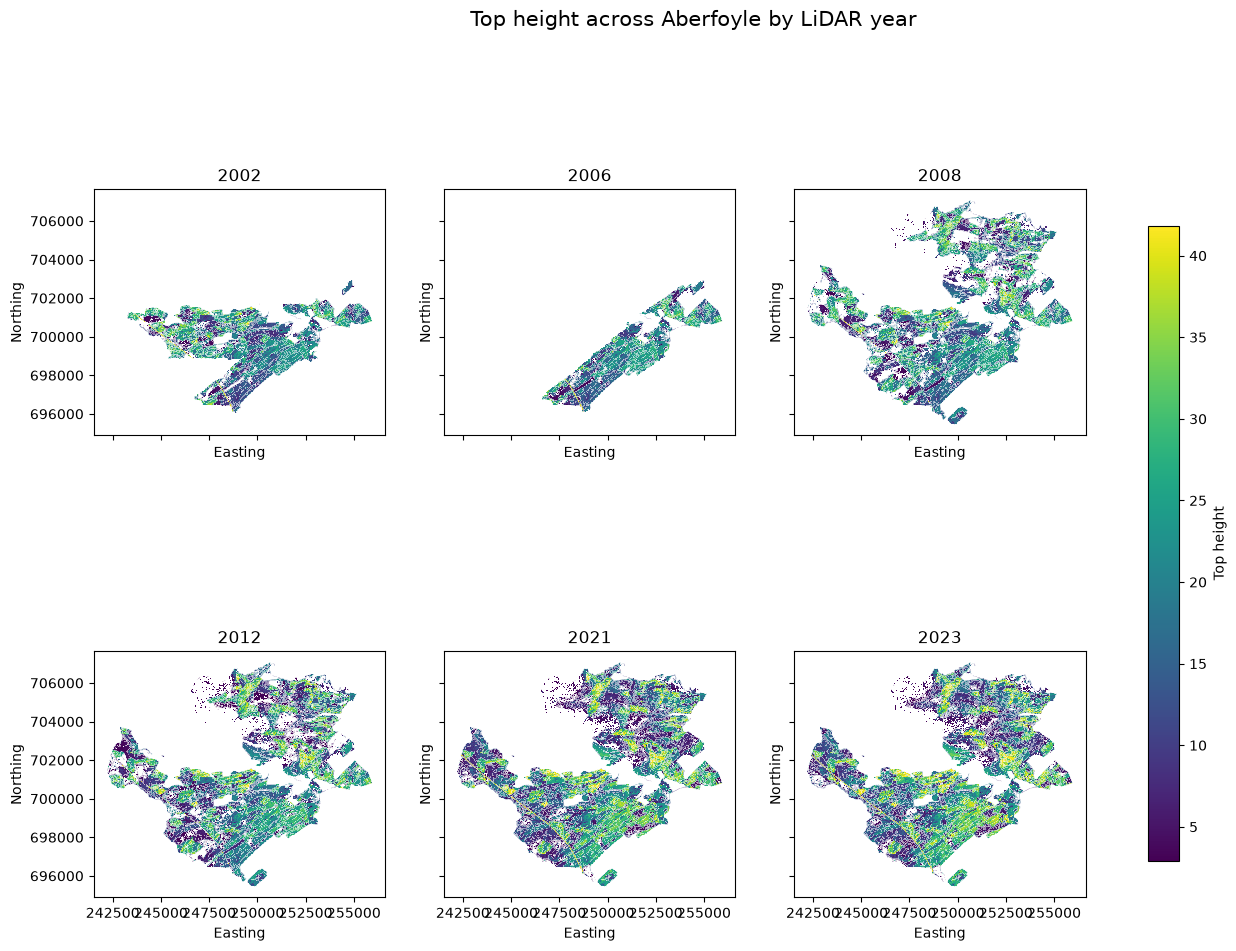

In [42]:
# Select Aberfoyle using a case-insensitive exact match.
aberfoyle = spatial_data.loc[
    spatial_data["AOI"].str.casefold().eq("aberfoyle")
].copy()

# Use one colour scale for all six years so colours are comparable.
# The 1st and 99th percentiles stop a few extremes dominating the colours;
# this clips only the display scale and does not remove any polygons.
height_min, height_max = aberfoyle["Top_Height"].quantile([0.01, 0.99])
fig, axes = plt.subplots(2, 3, figsize=(16, 11), sharex=True, sharey=True)

# Draw the original plot polygons at their real British National Grid coordinates.
for (year, year_data), axis in zip(aberfoyle.groupby("LiDAR_year"), axes.flat):
    year_data.plot(column="Top_Height", cmap="viridis",
                   vmin=height_min, vmax=height_max, linewidth=0, ax=axis)
    axis.set_title(str(year))
    axis.set_xlabel("Easting")
    axis.set_ylabel("Northing")
    axis.set_aspect("equal")

# Add one shared colour bar rather than a different scale for each panel.
colour_bar = plt.cm.ScalarMappable(norm=plt.Normalize(height_min, height_max), cmap="viridis")
fig.colorbar(colour_bar, ax=axes, label="Top height", shrink=0.75)
fig.suptitle("Top height across Aberfoyle by LiDAR year", fontsize=15)
fig.savefig(output_directory / "aberfoyle_top_height_by_year.png",
            dpi=300, bbox_inches="tight")
plt.show()

### 5.2 Spatial-map interpretation

Each panel shows the actual Aberfoyle plot polygons at their British National Grid coordinates. Colour represents top height, using the same scale in every year. Blank locations indicate places not covered in that survey, not necessarily treeless land.

The map can be used to identify broad spatial patterns, coverage changes, and clusters of unusually high or low forest. Visual differences between years are not automatically forest growth or loss because the set of available plots changes between surveys. A defensible temporal map comparison should use the balanced repeated-plot cohort.

### 5.3 Eligible trajectories

An **eligible trajectory** represents one plot observed exactly once in each of the four selected LiDAR surveys: 2008, 2012, 2021 and 2023.

A plot is considered eligible when:

- it has one record in each of the four survey years;
- every record is labelled as Sitka spruce (`SS`);
- the planting year is known and consistent across all records;
- the plot was at least 15 years old in 2008;
- all calculated ages are between 0 and 200 years;
- all top-height measurements are greater than 0 m and no greater than 150 m.

These rules remove incomplete trajectories, repeated plot–year records and clearly implausible age or height values.

Height decreases are **not** used to exclude plots. A decrease could represent clear-felling, windthrow, disease, other disturbance or measurement differences. Instead, height changes are classified and retained for separate interpretation.

Eligibility does not prove that the plot geometry remained identical, that the forest was undisturbed, or that the linked 2025 species and planting-year information accurately describes every historical survey.

In [55]:
# Categorise height change between consecutive surveys.
change = eligible_trajectories["height_change"]

conditions = [
    change.lt(-10),
    change.ge(-10) & change.lt(-5),
    change.ge(-5) & change.lt(-2),
    change.ge(-2) & change.lt(0),
    np.isclose(change, 0),
    change.gt(0) & change.le(2),
    change.gt(2) & change.le(5),
    change.gt(5) & change.le(10),
    change.gt(10),
]

categories = [
    "drop over 10 m",
    "drop 5–10 m",
    "drop 2–5 m",
    "small drop 0–2 m",
    "no change",
    "increase 0–2 m",
    "increase 2–5 m",
    "increase 5–10 m",
    "increase over 10 m",
]

eligible_trajectories["height_change_category"] = np.select(conditions,categories,default=None,)

# Add the previous survey year for clearer transition labels.
eligible_trajectories["previous_year"] = (eligible_trajectories.groupby("identification")["LiDAR_year"].shift())

# Count plots in each category for every transition.
height_change_summary = (eligible_trajectories.dropna(subset=["previous_year"])
    .groupby(
        ["previous_year","LiDAR_year","height_change_category",])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=categories, fill_value=0)
)
display(height_change_summary)
print("Number of eligible plots:", len(eligible_last_four_ids))



,height_change_category,drop over 10 m,drop 5–10 m,drop 2–5 m,small drop 0–2 m,no change,increase 0–2 m,increase 2–5 m,increase 5–10 m,increase over 10 m
previous_year,LiDAR_year,,,,,,,,,
2008.0,2012,119,126,174,634,0,6931,24813,147,1
2012.0,2021,211,123,209,695,0,3071,10660,17915,61
2021.0,2023,244,167,354,1336,0,17530,13262,48,4


Number of eligible plots: 32945


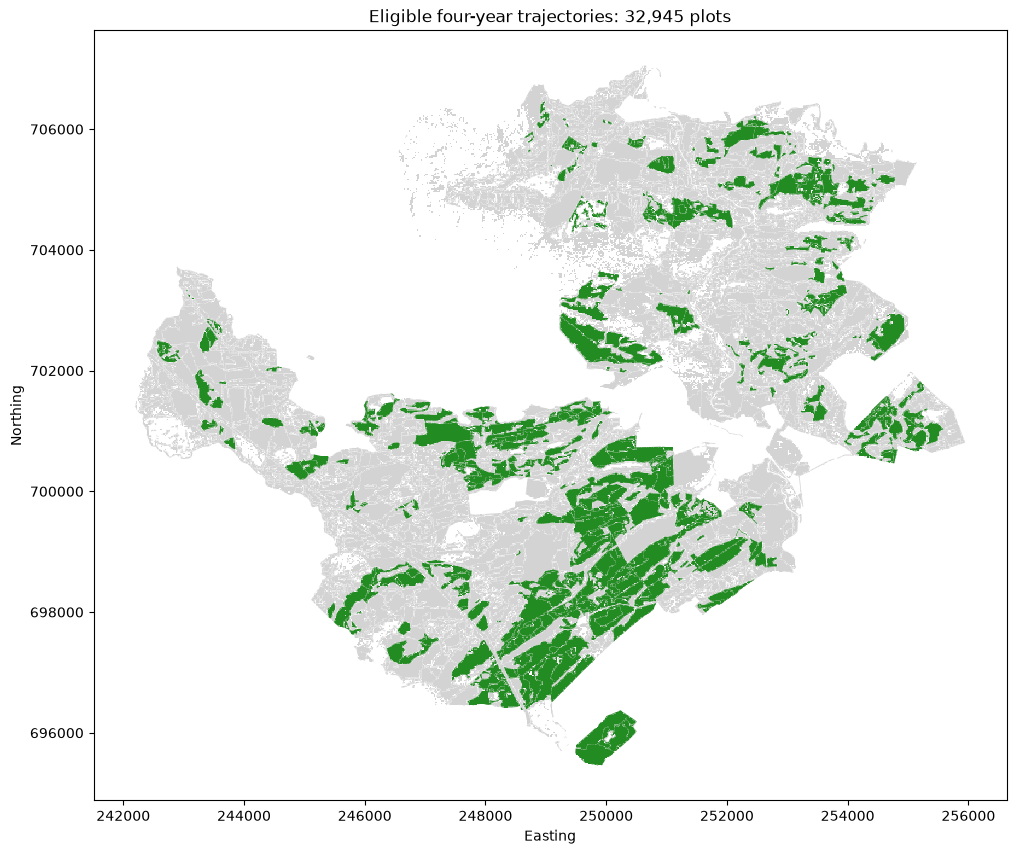

In [57]:
eligible_map = spatial_data.loc[
    spatial_data["identification"].isin(eligible_last_four_ids)
    & spatial_data["LiDAR_year"].eq(2023)
]

fig, axis = plt.subplots(figsize=(12, 10))

# Show all 2023 plots as background.
spatial_data.loc[
    spatial_data["LiDAR_year"].eq(2023)
].plot(
    ax=axis,
    color="lightgrey",
    linewidth=0,
)

# Highlight eligible plots.
eligible_map.plot(
    ax=axis,
    color="forestgreen",
    linewidth=0,
)

axis.set_title(
    f"Eligible four-year trajectories: {len(eligible_last_four_ids):,} plots"
)
axis.set_xlabel("Easting")
axis.set_ylabel("Northing")
axis.set_aspect("equal")

plt.show()

The main loss is not caused by planting year. It is caused by restricting the analysis to confirmed Sitka spruce and then requiring a minimum starting age of 15.

Selection funnel:

| Rule applied sequentially | Plots remaining |
|---|---:|
| Exactly one record in all four years | 93,152 |
| All records labelled Sitka spruce | 45,300 |
| Known, consistent planting year | 45,300 |
| Age between 0 and 200 | 42,866 |
| At least 15 years old in 2008 | 32,946 |
| Height between 0 and 150 m | 32,945 |

Key findings:

- The Sitka spruce rule removes **47,852 plots**—the largest reduction.
- The planting-year rule removes **no additional plots after the Sitka filter**. In this subset, confirmed Sitka plots already have consistent planting years.
- The plausible-age check removes another **2,434 plots**.
- The minimum age of 15 removes **9,920 otherwise usable plots**.
- The height check removes only **one plot**.

The 15-year threshold is not required simply to exclude planting during 2008–2023. Requiring a non-negative age in 2008 already means the planting year must be 2008 or earlier.

More importantly, excluding young stands may be counterproductive for fitting Chapman–Richards: young observations help identify the early curve and shape parameter. It would bias the analysis toward established stands.

I recommend:

- Keep the known/consistent planting-year and plausible-age rules for CR analysis.
- Remove `minimum_starting_age = 15` from general cleaning.
- Use the 15-year threshold only for a separate “established stands” sensitivity analysis.
- Retain the full dataset outside the CR-specific subset.

Removing the 15-year threshold would leave approximately **42,865 eligible plots**, rather than 32,945. The map would still exclude non-Sitka or unconfirmed-species plots, which explains much of its sparse spatial appearance.

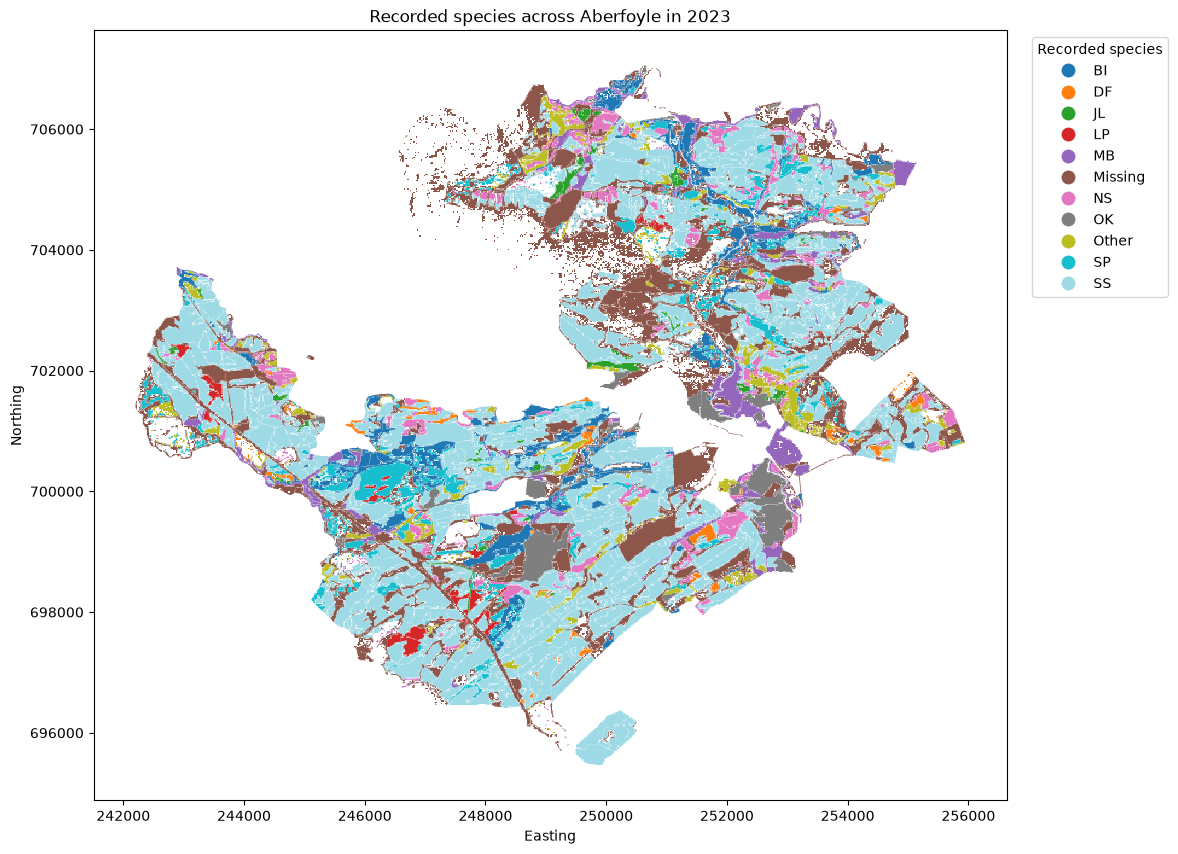

In [60]:
# Select the 2023 spatial records.
species_map_2023 = spatial_data.loc[spatial_data["LiDAR_year"].eq(2023)].copy()

# Keep missing species visible instead of dropping them.
species_map_2023["species_group"] = species_map_2023["spis"].fillna("Missing")

# Display the ten most common groups and combine the rest as "Other".
main_species = species_map_2023["species_group"].value_counts().head(10).index

species_map_2023["species_group"] = species_map_2023["species_group"].where(species_map_2023["species_group"].isin(main_species), "Other")

fig, axis = plt.subplots(figsize=(12, 10))

species_map_2023.plot(
    column="species_group",
    categorical=True,
    legend=True,
    cmap="tab20",
    linewidth=0,
    ax=axis,
    legend_kwds={
        "title": "Recorded species",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left",
    },
)

axis.set_title("Recorded species across Aberfoyle in 2023")
axis.set_xlabel("Easting")
axis.set_ylabel("Northing")
axis.set_aspect("equal")

plt.show()

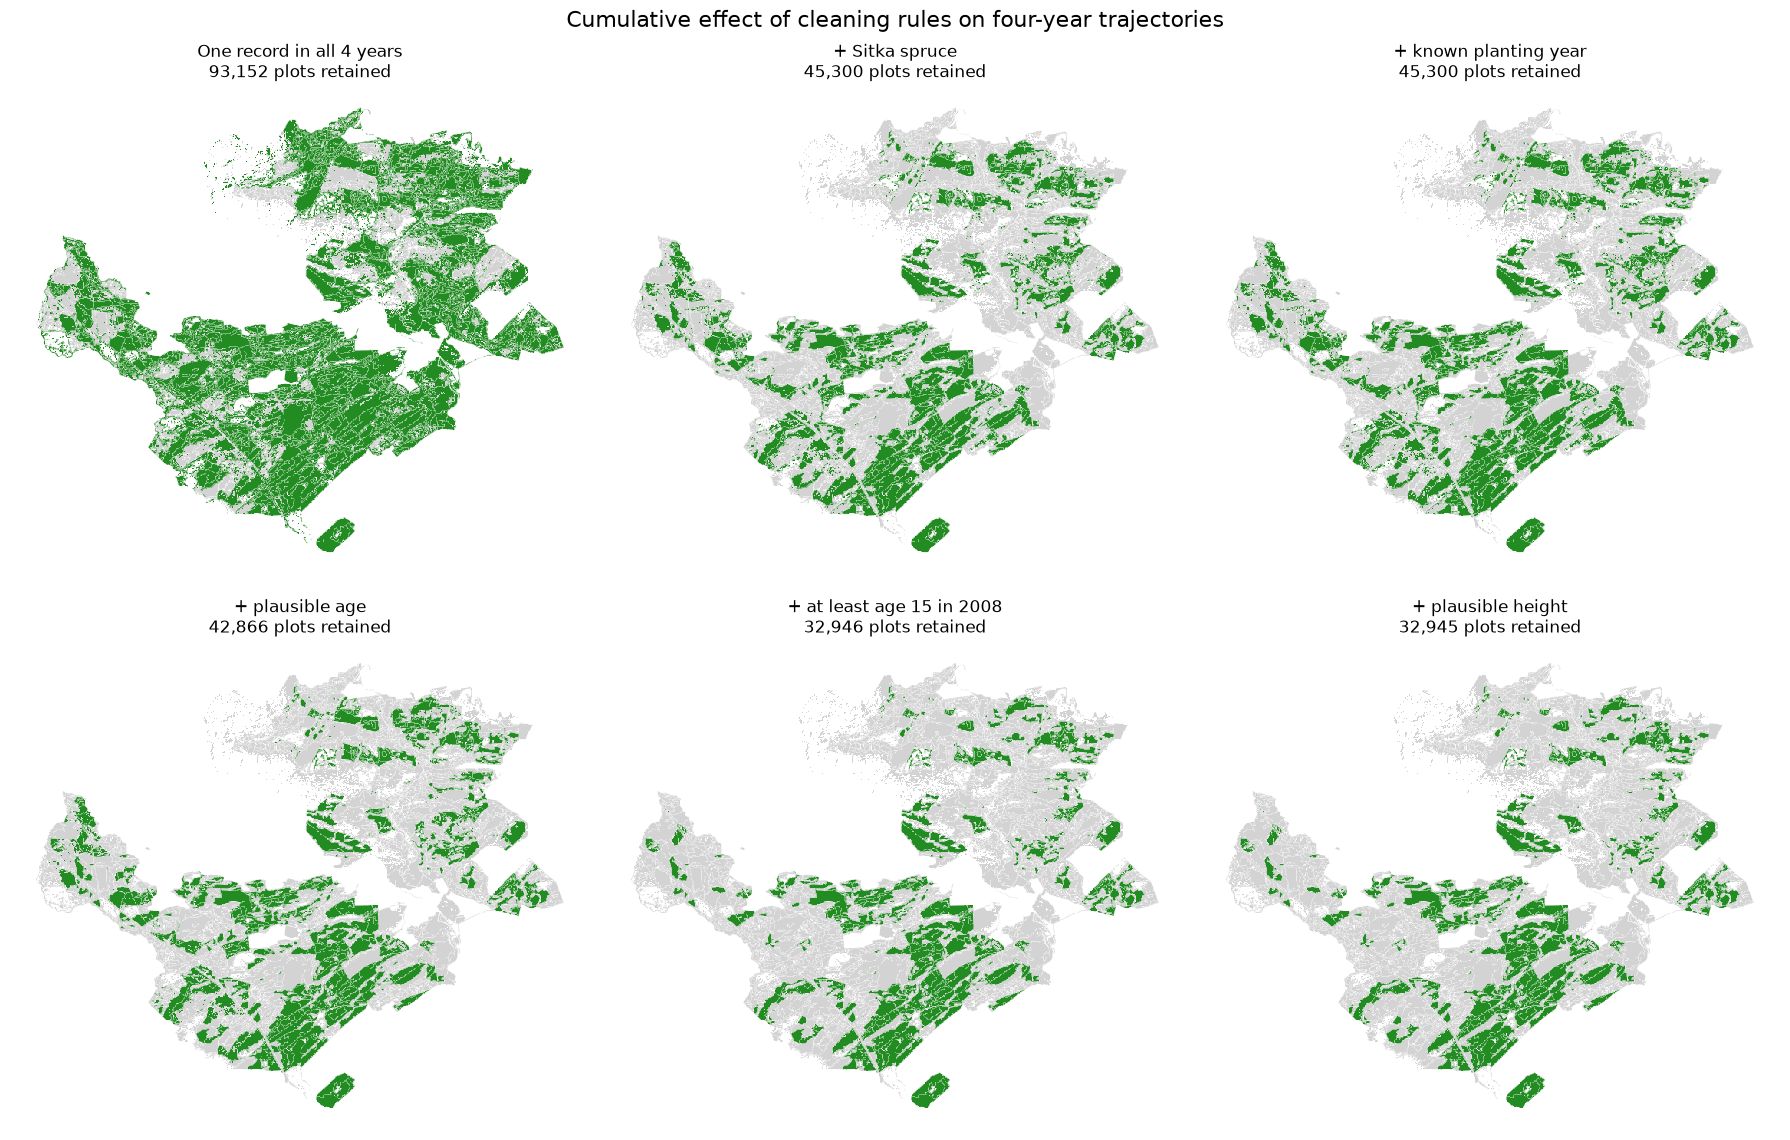

In [59]:
# Use one 2023 polygon per plot as the map background.
map_2023 = (spatial_data.loc[spatial_data["LiDAR_year"].eq(2023)].drop_duplicates("identification").copy())

# Build cumulative cleaning stages.
stage_1 = (last_four_checks["rows"].eq(4) & last_four_checks["survey_years"].eq(4))
stage_2 = (stage_1 & last_four_checks["all_sitka"])
stage_3 = (stage_2 & last_four_checks["planting_years"].eq(1) & last_four_checks["planting_year_known"])
stage_4 = (stage_3 & last_four_checks["all_ages_plausible"])
stage_5 = (stage_4 & last_four_checks["starting_age"].ge(15))
stage_6 = (stage_5 & last_four_checks["all_heights_plausible"])

cleaning_stages = {
    "One record in all 4 years": last_four_checks.index[stage_1],
    "+ Sitka spruce": last_four_checks.index[stage_2],
    "+ known planting year": last_four_checks.index[stage_3],
    "+ plausible age": last_four_checks.index[stage_4],
    "+ at least age 15 in 2008": last_four_checks.index[stage_5],
    "+ plausible height": last_four_checks.index[stage_6],
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)

for (stage_name, retained_ids), axis in zip(cleaning_stages.items(), axes.flat):
    retained = map_2023[map_2023["identification"].isin(retained_ids)]
    removed = map_2023[~map_2023["identification"].isin(retained_ids)]

    # Removed or unavailable plots.
    removed.plot(ax=axis, color="lightgrey", linewidth=0)

    # Plots retained at this cleaning stage.
    retained.plot(ax=axis, color="forestgreen", linewidth=0)

    axis.set_title(f"{stage_name}\n{len(retained_ids):,} plots retained")
    axis.set_axis_off()
    axis.set_aspect("equal")

fig.suptitle("Cumulative effect of cleaning rules on four-year trajectories", fontsize=16)

plt.tight_layout()

fig.savefig(output_directory / "cleaning_stages_spatial_map.png", dpi=300, bbox_inches="tight")

plt.show()

### 5.4 Six-year cleaning and spatial coverage

This section repeats the cumulative cleaning exercise for plots observed from 2002 to 2023. It requires exactly one record in each of all six surveys, then applies the Sitka spruce, planting-year, age and height rules. The minimum starting age of 15 years is retained as an established-stand sensitivity rule, not as essential general cleaning.

In [61]:
# Create row-level flags before summarising every plot ID.
six_year_data = attribute_table.copy()
six_year_data["is_sitka"] = six_year_data["spis"].fillna("").eq("SS")
six_year_data["planting_known"] = six_year_data["plyr"].gt(0)
six_year_data["known_planting_year"] = six_year_data["plyr"].where(
    six_year_data["plyr"].gt(0)
)
six_year_data["age_plausible"] = six_year_data["Age"].between(0, 200)
six_year_data["height_plausible"] = (
    six_year_data["Top_Height"].gt(0)
    & six_year_data["Top_Height"].le(150)
)

# Reduce the six survey records to one cleaning summary per plot.
six_year_checks = (
    six_year_data.groupby("identification")
    .agg(
        rows=("LiDAR_year", "size"),
        survey_years=("LiDAR_year", "nunique"),
        all_sitka=("is_sitka", "all"),
        planting_known=("planting_known", "all"),
        planting_years=("known_planting_year", "nunique"),
        all_ages_plausible=("age_plausible", "all"),
        starting_age=("Age", "min"),
        all_heights_plausible=("height_plausible", "all"),
    )
)

# Apply each rule cumulatively so its additional effect can be measured.
six_stage_1 = six_year_checks["rows"].eq(6) & six_year_checks["survey_years"].eq(6)
six_stage_2 = six_stage_1 & six_year_checks["all_sitka"]
six_stage_3 = (six_stage_2 & six_year_checks["planting_known"]
               & six_year_checks["planting_years"].eq(1))
six_stage_4 = six_stage_3 & six_year_checks["all_ages_plausible"]
six_stage_5 = six_stage_4 & six_year_checks["starting_age"].ge(15)
six_stage_6 = six_stage_5 & six_year_checks["all_heights_plausible"]

six_year_stages = {
    "One record in all 6 years": six_stage_1,
    "+ Sitka spruce": six_stage_2,
    "+ known planting year": six_stage_3,
    "+ plausible age": six_stage_4,
    "+ at least age 15 in 2002": six_stage_5,
    "+ plausible height": six_stage_6,
}

# Build a table showing retention and the additional loss at each stage.
funnel_rows = []
previous_count = None
first_count = int(six_stage_1.sum())
for stage_name, stage_mask in six_year_stages.items():
    retained_count = int(stage_mask.sum())
    funnel_rows.append({
        "cleaning_stage": stage_name,
        "plots_retained": retained_count,
        "plots_dropped_at_stage": (
            0 if previous_count is None else previous_count - retained_count
        ),
        "percentage_of_first_stage_retained": round(
            retained_count / first_count * 100, 2
        ),
    })
    previous_count = retained_count

six_year_cleaning_table = pd.DataFrame(funnel_rows)
six_year_eligible_ids = six_year_checks.index[six_stage_6]
display(six_year_cleaning_table)
print(f"Final six-year established-stand plots: {len(six_year_eligible_ids):,}")

,cleaning_stage,plots_retained,plots_dropped_at_stage,percentage_of_first_stage_retained
0,One record in all 6 years,26323,0,100.00
1,+ Sitka spruce,14567,11756,55.34
2,+ known planting year,14567,0,55.34
3,+ plausible age,13873,694,52.70
4,+ at least age 15 in 2002,10963,2910,41.65
5,+ plausible height,10963,0,41.65


Final six-year established-stand plots: 10,963


**Six-year cleaning interpretation**

Requiring exactly one observation in all six surveys leaves 26,323 plots. Confirmed Sitka spruce reduces this to 14,567. The known, consistent planting-year rule removes no additional plots after the Sitka filter; plausible age reduces the total to 13,873. Requiring plots to be at least 15 years old in 2002 leaves 10,963, while the height rule removes no further plots.

The largest losses therefore come from longitudinal coverage and the confirmed Sitka spruce restriction. The 15-year rule removes 2,910 otherwise plausible trajectories and should remain a sensitivity choice rather than automatic cleaning. Without that age-15 restriction, the core six-year CR subset contains 13,873 plots.

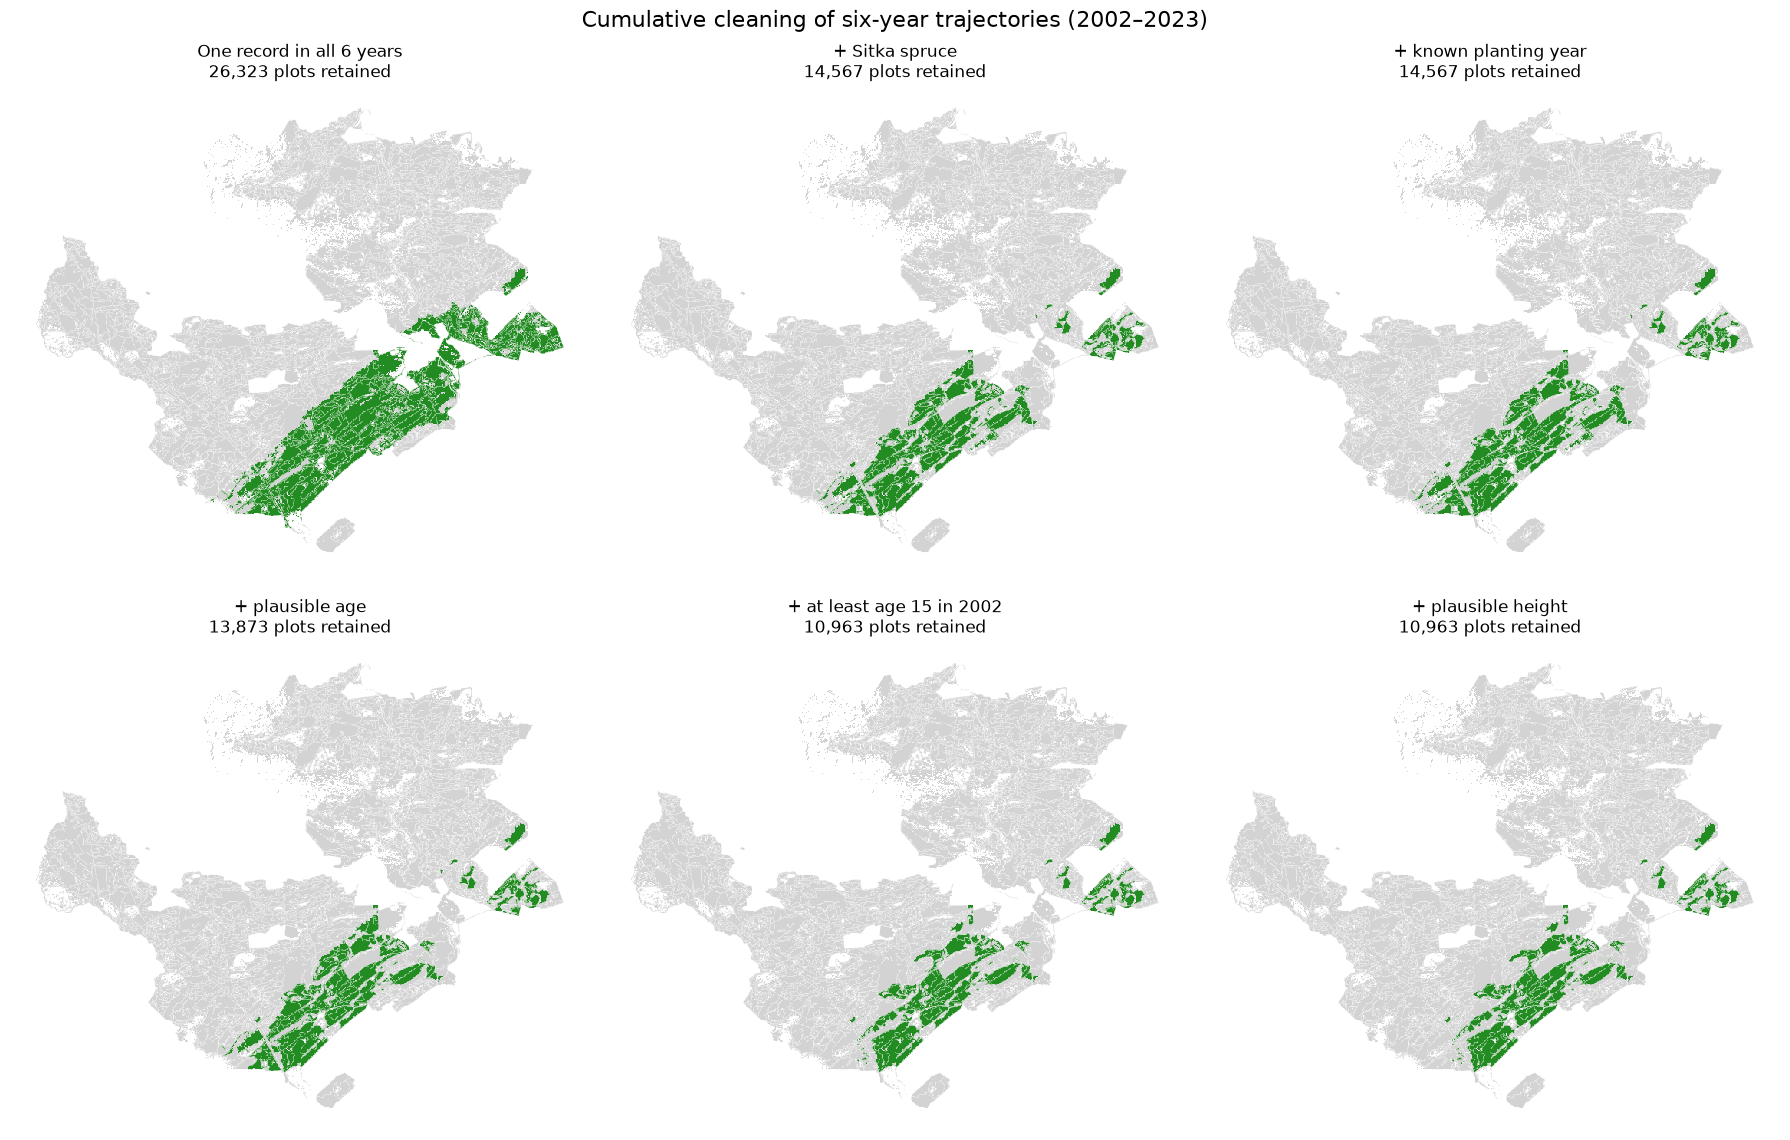

In [62]:
# Use one 2023 polygon per plot so every trajectory is mapped once.
six_year_map_2023 = (
    spatial_data.loc[spatial_data["LiDAR_year"].eq(2023)]
    .drop_duplicates("identification")
    .copy()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)

for (stage_name, stage_mask), axis in zip(six_year_stages.items(), axes.flat):
    retained_ids = six_year_checks.index[stage_mask]
    retained = six_year_map_2023[
        six_year_map_2023["identification"].isin(retained_ids)
    ]
    removed = six_year_map_2023[
        ~six_year_map_2023["identification"].isin(retained_ids)
    ]

    removed.plot(ax=axis, color="lightgrey", linewidth=0)
    retained.plot(ax=axis, color="forestgreen", linewidth=0)
    axis.set_title(f"{stage_name}\n{len(retained_ids):,} plots retained")
    axis.set_axis_off()
    axis.set_aspect("equal")

fig.suptitle("Cumulative cleaning of six-year trajectories (2002–2023)", fontsize=16)
plt.tight_layout()
fig.savefig(output_directory / "six_year_cleaning_stages_map.png",
            dpi=300, bbox_inches="tight")
plt.show()

# 6. Exploratory Chapman–Richards growth trajectories

The Chapman–Richards equation is:

$$y(t) = y_{max}[1-e^{-kt}]^p$$

where $y(t)$ is predicted top height at age $t$, $y_{max}$ is asymptotic maximum height, $k$ is the growth-rate parameter, and $p$ controls curve shape. This section does not fit the equation. It Rueben's provisional curve ($y_{max}=46.11$, $k=0.01867$, $p=1.0175$) with a reproducible random sample of plots. The source and applicability of these parameters must be verified before they are used in the dissertation or modelling.

## 6.1 Select plots likely to remain after cleaning

A candidate plot must: (1) occur exactly once in each of the six surveys; (2) be labelled Sitka spruce (`SS`) in every row; (3) have one consistent planting year greater than zero; (4) have calculated age from 0 to 200 years in every survey; and (5) have top height above 0 and no greater than 150 m in every survey. These are provisional rules. They reduce obvious data problems but do not confirm unchanged geometry, absence of harvesting, or historical correctness of the 2025 species and planting information.

In [43]:
# Summarise the cleaning conditions for every plot ID.
plot_checks = (
    attribute_table.groupby("identification")
    .agg(
        rows=("LiDAR_year", "size"),
        survey_years=("LiDAR_year", "nunique"),
        all_sitka=("spis", lambda values: values.fillna("").eq("SS").all()),
        planting_years=("plyr", lambda values: values[values.gt(0)].nunique()),
        all_planting_years_known=("plyr", lambda values: values.gt(0).all()),
        all_ages_plausible=("Age", lambda values: values.between(0, 200).all()),
        all_heights_plausible=("Top_Height", lambda values: values.between(0, 150, inclusive="right").all()),
    )
)

# Exactly six rows and six years means one observation in every survey,
# with no unresolved repeated plot/year record.
eligible_mask = (
    plot_checks["rows"].eq(6)
    & plot_checks["survey_years"].eq(6)
    & plot_checks["all_sitka"]
    & plot_checks["planting_years"].eq(1)
    & plot_checks["all_planting_years_known"]
    & plot_checks["all_ages_plausible"]
    & plot_checks["all_heights_plausible"]
)
eligible_plot_ids = plot_checks.index[eligible_mask]

# Use a fixed seed so the same random plots are selected every time.
number_to_plot = min(6, len(eligible_plot_ids))
selected_plot_ids = (
    pd.Series(eligible_plot_ids).sample(number_to_plot, random_state=42).tolist()
)
selected_plot_data = (
    attribute_table[attribute_table["identification"].isin(selected_plot_ids)]
    .sort_values(["identification", "Age"])
)

print(f"Eligible plots: {len(eligible_plot_ids):,}")
print("Randomly selected plot IDs:", selected_plot_ids)
display(selected_plot_data[["identification", "LiDAR_year", "Age", "Top_Height", "spis"]])

Eligible plots: 13,873
Randomly selected plot IDs: [319737, 153848, 357317, 238092, 234543, 77464]


,identification,LiDAR_year,Age,Top_Height,spis
47917,77464,2002,11,9.698659,SS
55810,77464,2006,15,12.766556,SS
92701,77464,2008,17,14.303303,SS
196623,77464,2012,21,19.011849,SS
308706,77464,2021,30,27.075875,SS
433444,77464,2023,32,29.044981,SS
7502,153848,2002,33,21.879248,SS
67101,153848,2006,37,23.855533,SS
141033,153848,2008,39,24.536438,SS
248295,153848,2012,43,27.548195,SS


## 6.2 Compare observed heights with the provisional curve

Each panel shows the six observed top-height measurements for one plot. The dashed line is the same supplied Chapman–Richards curve in every panel. Agreement means the observations are near the curve; systematic vertical or shape differences indicate that one global parameter set does not describe every plot.

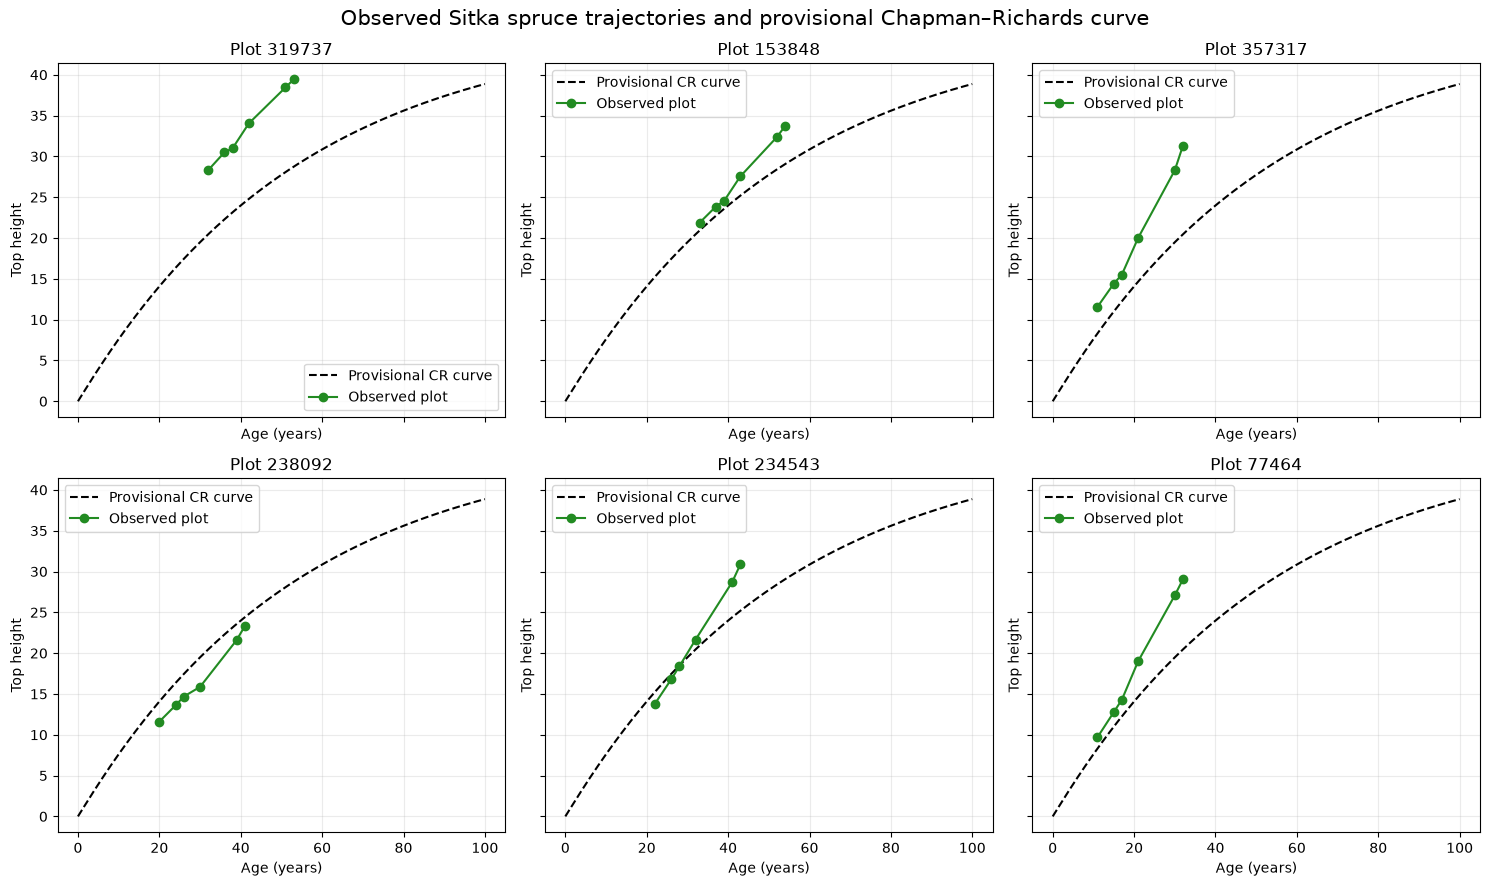

In [44]:
# Supplied provisional Chapman–Richards parameters.
y_max = 46.11
k = 0.01867
p = 1.0175

# Calculate a smooth reference curve over the selected plots' age range.
maximum_age = max(100, selected_plot_data["Age"].max() + 10)
curve_age = np.linspace(0, maximum_age, 400)
curve_height = y_max * (1 - np.exp(-k * curve_age)) ** p

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)

for plot_id, axis in zip(selected_plot_ids, axes.flat):
    plot_data = selected_plot_data[selected_plot_data["identification"].eq(plot_id)]
    axis.plot(curve_age, curve_height, color="black", linestyle="--",
              label="Provisional CR curve")
    axis.plot(plot_data["Age"], plot_data["Top_Height"],
              marker="o", color="forestgreen", label="Observed plot")
    axis.set_title(f"Plot {plot_id}")
    axis.set_xlabel("Age (years)")
    axis.set_ylabel("Top height")
    axis.grid(alpha=0.25)
    axis.legend()

# Hide unused panels if fewer than six plots are eligible.
for axis in axes.flat[len(selected_plot_ids):]:
    axis.set_visible(False)

fig.suptitle("Observed Sitka spruce trajectories and provisional Chapman–Richards curve", fontsize=15)
plt.tight_layout()
fig.savefig(output_directory / "chapman_richards_random_plots.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [45]:
# Quantify alignment as observed height minus predicted height.
selected_plot_data = selected_plot_data.copy()
selected_plot_data["CR_predicted_height"] = (
    y_max * (1 - np.exp(-k * selected_plot_data["Age"])) ** p
)
selected_plot_data["CR_residual"] = (
    selected_plot_data["Top_Height"] - selected_plot_data["CR_predicted_height"]
)

alignment_summary = (
    selected_plot_data.groupby("identification")
    .agg(
        observations=("CR_residual", "size"),
        mean_residual=("CR_residual", "mean"),
        RMSE=("CR_residual", lambda values: np.sqrt(np.mean(values ** 2))),
    )
    .round(2)
)
display(alignment_summary)

,observations,mean_residual,RMSE
identification,,,
77464,6,4.29,5.16
153848,6,2.34,2.78
234543,6,1.49,3.02
238092,6,-2.44,2.56
319737,6,9.04,9.11
357317,6,5.83,6.55


## 6.3 Interpretation limits

A positive residual means observed top height is above the provisional curve; a negative residual means it is below. RMSE summarises the typical vertical discrepancy for each sampled plot. These diagnostics do not validate the equation: six hand-filtered plots are a visual check only, and the supplied parameters may have been estimated from the same dataset.

Before fitting or evaluating a growth model, repeated geometry should be confirmed, disturbance or harvesting should be considered, and training and validation plots should be spatially separated. Plot-specific trajectories may differ because of yield class, site conditions, management, measurement error, or an incorrect historical planting year.

In [50]:
last_four_years = [2008, 2012, 2021, 2023]
minimum_starting_age = 15

last_four_data = attribute_table[
    attribute_table["LiDAR_year"].isin(last_four_years)
].copy()

last_four_checks = (
    last_four_data.groupby("identification")
    .agg(
        # Exactly four rows and four years means one record per survey.
        rows=("LiDAR_year", "size"),
        survey_years=("LiDAR_year", "nunique"),
        all_sitka=("spis",lambda x: x.fillna("").eq("SS").all(),), # Require Sitka spruce in every survey record.
        planting_years=("plyr",lambda x: x[x.gt(0)].nunique(),),# Require one consistent, non-zero planting year.
        planting_year_known=("plyr",lambda x: x.gt(0).all(),),
        starting_age=("Age", "min"), # Age at the beginning of the four-survey period.
        all_ages_plausible=("Age",lambda x: x.between(0, 200).all(),), # Apply broad plausibility checks.
        all_heights_plausible=("Top_Height",lambda x: x.between(0, 150, inclusive="right").all(),
        ),
    )
)

eligible_last_four = (
    last_four_checks["rows"].eq(4)
    & last_four_checks["survey_years"].eq(4)
    & last_four_checks["all_sitka"]
    & last_four_checks["planting_years"].eq(1)
    & last_four_checks["planting_year_known"]
    & last_four_checks["starting_age"].ge(
        minimum_starting_age
    )
    & last_four_checks["all_ages_plausible"]
    & last_four_checks["all_heights_plausible"]
)

eligible_last_four_ids = last_four_checks.index[
    eligible_last_four
]

print(
    "Eligible plots:",
    len(eligible_last_four_ids),
)

Eligible plots: 32945


In [51]:
eligible_trajectories = (
    last_four_data[
        last_four_data["identification"].isin(
            eligible_last_four_ids
        )
    ]
    .sort_values(["identification", "LiDAR_year"])
    .copy()
)

eligible_trajectories["height_change"] = (
    eligible_trajectories.groupby(
        "identification"
    )["Top_Height"].diff()
)

# A drop greater than 2 m is flagged for investigation.
eligible_trajectories["possible_disturbance"] = (
    eligible_trajectories["height_change"].lt(-2)
)

disturbance_by_plot = (
    eligible_trajectories.groupby(
        "identification"
    )["possible_disturbance"]
    .any()
)

print(
    "Plots with a height drop over 2 m:",
    disturbance_by_plot.sum(),
)

print(
    "Plots without a height drop over 2 m:",
    (~disturbance_by_plot).sum(),
)

Plots with a height drop over 2 m: 1547
Plots without a height drop over 2 m: 31398


## 6.4 Yield Class 16 comparison

Forest Research provides Sitka spruce General Yield Class top-height/age curves, including YC16, but the official documentation does not publish a YC16 Chapman–Richards parameter triplet. It describes the historical top-height curves as a family of productivity curves rather than as this specific equation. Therefore, a YC16 CR curve is not invented here.

Instead, this exploratory check selects cleaned plots labelled YC16 and compares their observations with the same provisional CR curve used above. This asks whether the supplied general curve happens to align with YC16 plots; it does **not** turn that curve into an official YC16 model. An authoritative YC16 reference should later be exported from Forest Research's [Forest Yield](https://www.forestresearch.gov.uk/tools-and-resources/fthr/forest-yield/) software or transcribed from its published GYC curve with the method documented.